# Employee Attrition Prediction & Sentiment Analysis with Explainable Deep Learning

This notebook contains two complete deep-learning pipelines that work together to study why
employees leave a company.

- **Part 1 — Attrition Prediction.** Using an HR analytics dataset, we explore the data in
  detail and then train two tabular deep-learning models (an FT-Transformer and a Tabular
  ResNet) to predict whether an employee will leave. We also explain *why* each prediction is
  made using attention weights and SHAP.
- **Part 2 — Sentiment Analysis.** Using employee reviews, we train two text models (a BiLSTM
  and a CNN-BiGRU with attention) to classify review sentiment, then turn that sentiment into
  an attrition-risk signal. Word-level explanations are produced with LIME and SHAP.

Every random step is controlled by a single seed so the whole notebook reproduces the same
results on each run.

# Part 1 — Employee Attrition Prediction

We start with the structured HR data: load it, understand it, explore it visually, run a few
statistical tests, prepare it for modelling, and finally train and explain two models.

## 1. Import Libraries and Set the Random Seed

We import everything Part 1 needs and fix one global seed. Fixing the seed makes the data
split, the model's starting weights, the batch order and the augmentation identical on every run.

In [3]:
# Core data and plotting libraries
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

# Scikit-learn helpers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score,
                             average_precision_score, precision_recall_curve)

# PyTorch (used for the deep-learning models)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# One seed controls all randomness in this notebook
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Libraries imported. SEED =", SEED)

Libraries imported. SEED = 42


## 2. Load the Dataset

We load the HR analytics dataset into a single DataFrame called `df`.

In [4]:
# Load the HR dataset
import glob, os

BASE = "/kaggle/input/datasets/arashnic/hr-analytics-job-change-of-data-scientists"
matches = (glob.glob(os.path.join(BASE, "**", "aug_train.csv"), recursive=True)
           or glob.glob(os.path.join(BASE, "**", "*.csv"), recursive=True))
df = pd.read_csv(matches[0])
print("Loaded:", matches[0])

# This dataset's label is 'target' (0/1); the pipeline works with Yes/No Attrition.
if 'target' in df.columns:
    df = df.rename(columns={'target': 'Attrition'})
df['Attrition'] = df['Attrition'].map({1: 'Yes', 0: 'No', '1': 'Yes', '0': 'No'})

# Impute missing values (features only): text -> 'Unknown', numeric -> median
for _c in df.columns:
    if _c == 'Attrition':
        continue
    if df[_c].dtype == 'object':
        df[_c] = df[_c].fillna('Unknown')
    else:
        df[_c] = df[_c].fillna(df[_c].median())

print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print(df['Attrition'].value_counts())
df.head()

Loaded: /kaggle/input/datasets/arashnic/hr-analytics-job-change-of-data-scientists/aug_train.csv
Rows: 19158 | Columns: 14
Attrition
No     14381
Yes     4777
Name: count, dtype: int64


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,Attrition
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,Yes
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,No
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,No
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,Yes
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,No


## 3. Understand the Data

Before any modelling we look at the size, structure and quality of the data: a few sample
rows, the column list, data types, missing values, duplicates and memory use.

**First five rows**

In [5]:
# Display first 5 records
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,Attrition
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,Yes
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,No
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,No
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,Yes
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,No


**Last five rows**

In [6]:
df.tail()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,Attrition
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,Unknown,Unknown,1,42,Yes
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,Unknown,Unknown,4,52,Yes
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,No
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,Unknown,<1,500-999,Pvt Ltd,2,97,No
19157,23834,city_67,0.855,Unknown,No relevent experience,no_enrollment,Primary School,Unknown,2,Unknown,Unknown,1,127,No


**A random sample of rows**

In [7]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,Attrition
16144,6992,city_16,0.910,Unknown,Has relevent experience,no_enrollment,Graduate,STEM,6,500-999,Pvt Ltd,1,21,No
13661,8637,city_103,0.920,Female,Has relevent experience,no_enrollment,Masters,Humanities,>20,100-500,Funded Startup,2,74,No
344,24729,city_104,0.924,Unknown,Has relevent experience,no_enrollment,Graduate,STEM,9,10/49,Pvt Ltd,1,94,No
1034,10933,city_21,0.624,Male,Has relevent experience,no_enrollment,Masters,STEM,15,10000+,Pvt Ltd,1,75,No
8109,28023,city_134,0.698,Male,No relevent experience,no_enrollment,Masters,STEM,12,500-999,NGO,1,157,No


**Shape of the dataset**

In [8]:
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (19158, 14)
Rows: 19158
Columns: 14


**Column names**

In [9]:
print(df.columns)

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'Attrition'],
      dtype='object')


**Column overview (types and non-null counts)**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  19158 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     19158 non-null  object 
 6   education_level         19158 non-null  object 
 7   major_discipline        19158 non-null  object 
 8   experience              19158 non-null  object 
 9   company_size            19158 non-null  object 
 10  company_type            19158 non-null  object 
 11  last_new_job            19158 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  Attrition               19158 non-null  object 
dtypes: float64(1), int64(2), object(11)
me

**Data types of each column**

In [11]:
df.dtypes

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
Attrition                  object
dtype: object

**Missing values (columns that have any)**

In [12]:
# Count missing values in every column
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

**Missing values as a percentage**

In [13]:
# Percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

enrollee_id               0.0
city                      0.0
city_development_index    0.0
gender                    0.0
relevent_experience       0.0
enrolled_university       0.0
education_level           0.0
major_discipline          0.0
experience                0.0
company_size              0.0
company_type              0.0
last_new_job              0.0
training_hours            0.0
Attrition                 0.0
dtype: float64

**Duplicate rows**

In [14]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


**Number of unique values per column**

In [15]:
df.nunique()

enrollee_id               19158
city                        123
city_development_index       93
gender                        4
relevent_experience           2
enrolled_university           4
education_level               6
major_discipline              7
experience                   23
company_size                  9
company_type                  7
last_new_job                  7
training_hours              241
Attrition                     2
dtype: int64

**Memory used by the dataset**

In [16]:
print("Memory Usage:", round(df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

Memory Usage: 11.78 MB


**Split the columns into numerical and categorical groups**

In [17]:
# Separate numeric and categorical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['enrollee_id', 'city_development_index', 'training_hours'], dtype='object')

Categorical Features:
Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job', 'Attrition'],
      dtype='object')


**A single data-quality summary table**

In [18]:
quality_report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2),
    'Unique Values': df.nunique()
})

quality_report

,Data Type,Missing Values,Missing %,Unique Values
enrollee_id,int64,0,0.0,19158
city,object,0,0.0,123
city_development_index,float64,0,0.0,93
gender,object,0,0.0,4
relevent_experience,object,0,0.0,2
enrolled_university,object,0,0.0,4
education_level,object,0,0.0,6
major_discipline,object,0,0.0,7
experience,object,0,0.0,23
company_size,object,0,0.0,9


## 4. Descriptive Statistics

We summarise the numeric columns, check how skewed they are, look at correlations, and see how
balanced the target (`Attrition`) is. We also drop four columns that hold the same value for
every employee or are just identifiers, because they cannot help a model.

**Statistical summary of numeric columns**

In [19]:
# Mean, std, min, quartiles and max for numeric columns
df.describe()

,enrollee_id,city_development_index,training_hours
count,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896
std,9616.292592,0.123362,60.058462
min,1.000000,0.448000,1.000000
25%,8554.250000,0.740000,23.000000
50%,16982.500000,0.903000,47.000000
75%,25169.750000,0.920000,88.000000
max,33380.000000,0.949000,336.000000


**Skewness** — how lop-sided each numeric column is.

In [20]:
# Skewness of numeric columns
skewness = df.skew(numeric_only=True)
print(skewness)

enrollee_id              -0.018391
city_development_index   -0.995428
training_hours            1.819237
dtype: float64


**Kurtosis** — how heavy the tails of each numeric column are.

In [21]:
# Kurtosis of numeric columns
kurtosis = df.kurtosis(numeric_only=True)
print(kurtosis)

enrollee_id              -1.196157
city_development_index   -0.538532
training_hours            3.840539
dtype: float64


**Correlation matrix** of the numeric columns.

In [22]:
# Correlation between numeric columns
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,enrollee_id,city_development_index,training_hours
enrollee_id,1.000000,-0.040455,0.000998
city_development_index,-0.040455,1.000000,0.001920
training_hours,0.000998,0.001920,1.000000


**Target balance** — how many employees stay vs leave.

In [23]:
# How many employees stay (No) vs leave (Yes)
df['Attrition'].value_counts()

Attrition
No     14381
Yes     4777
Name: count, dtype: int64

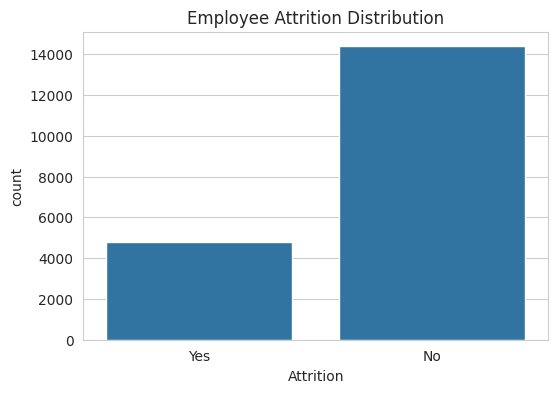

In [24]:
# Plot the attrition balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df)
plt.title('Employee Attrition Distribution')
plt.show()

**Drop constant and ID columns.** These four columns add no information for prediction.

In [25]:
# Constant columns and identifier columns cannot help a model — find them automatically
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
id_cols    = [c for c in df.columns
              if c.lower().endswith('id')
              or (df[c].dtype == 'object' and df[c].nunique() == len(df))]
drop_cols  = list(dict.fromkeys(const_cols + id_cols))
print("Constant columns  :", const_cols)
print("Identifier columns:", id_cols)
drop_cols


Constant columns  : []
Identifier columns: ['enrollee_id']


['enrollee_id']

In [26]:
# Remove the non-informative columns found above
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print("Shape after dropping:", df.shape)


Shape after dropping: (19158, 13)


## 5. Exploratory Data Analysis — One Feature at a Time

We look at the shape of each numeric feature with histograms and box-plots, and the balance of
each categorical feature with count-plots.

**List of numeric features to plot**

In [27]:
# Numeric features (all numeric columns except the target)
numerical_features = [c for c in df.select_dtypes(include=[np.number]).columns
                      if c != 'Attrition']
print(numerical_features)


['city_development_index', 'training_hours']


**Histograms** of each numeric feature.

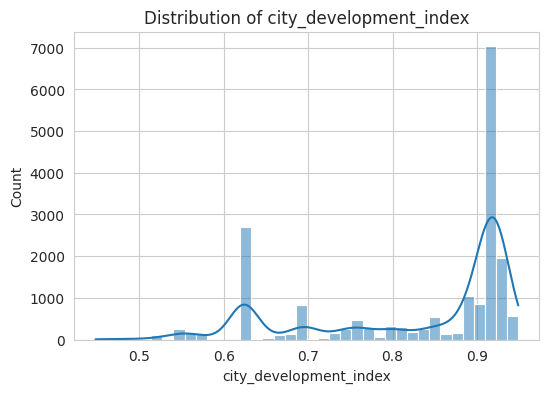

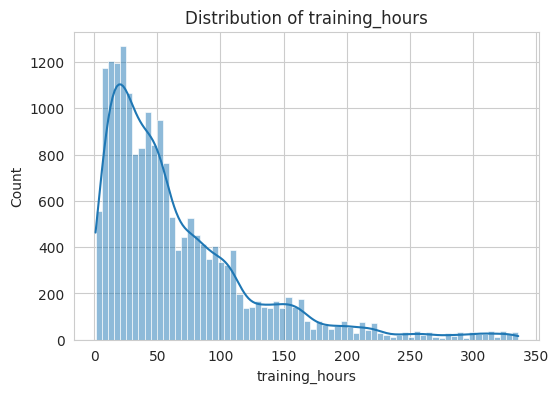

In [28]:
# Histogram for every numeric feature
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

**Box-plots** of each numeric feature (useful for spotting outliers).

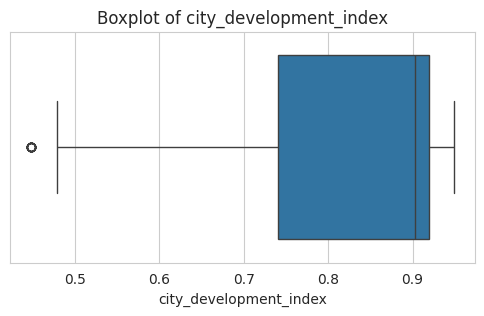

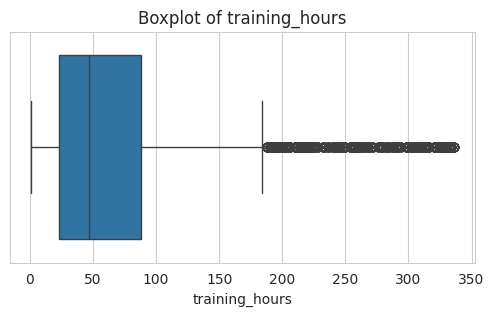

In [29]:
# Box-plot for every numeric feature
for col in numerical_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

**List of categorical features to plot**

In [30]:
# Categorical columns (non-numeric), keeping the target in the list for reference
categorical_features = [c for c in df.columns if c not in numerical_features]
print(categorical_features)


['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'Attrition']


**Count-plots** of each categorical feature.

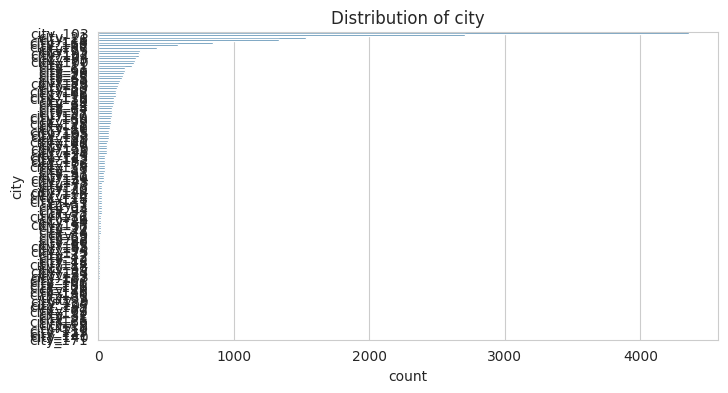

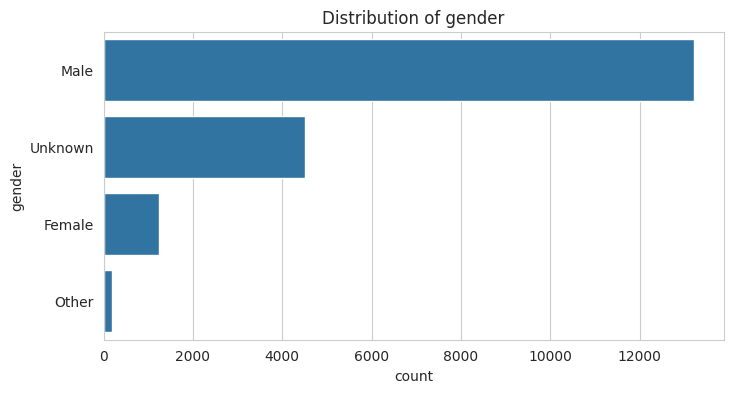

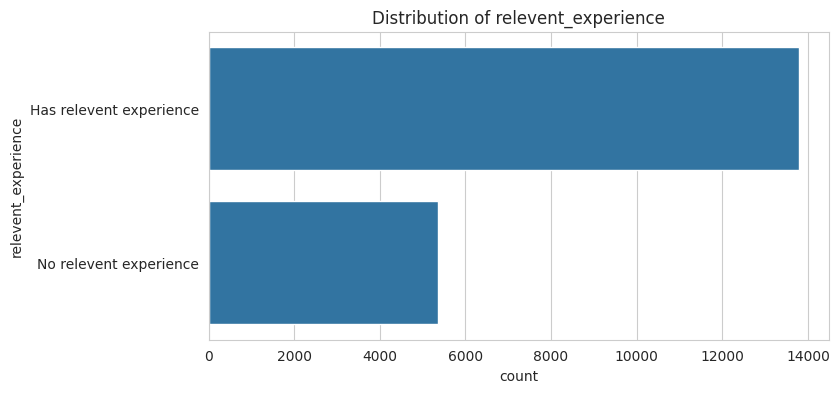

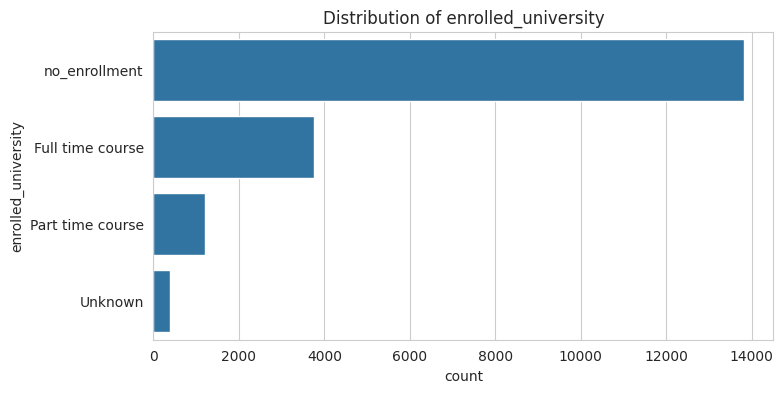

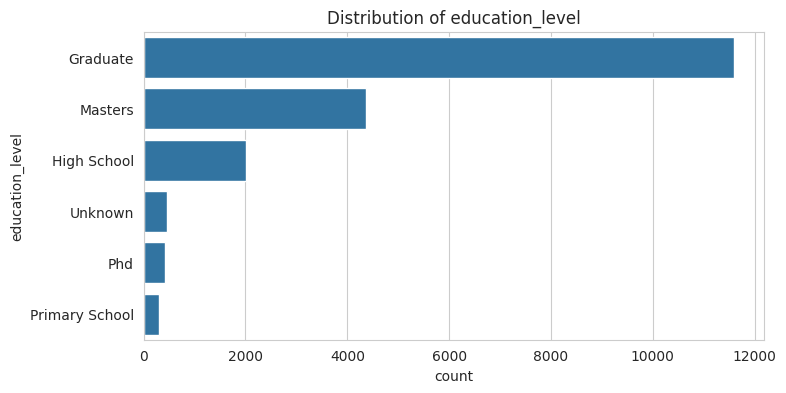

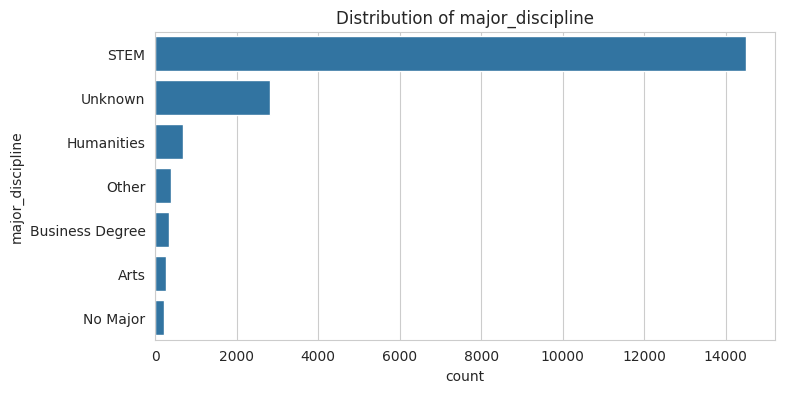

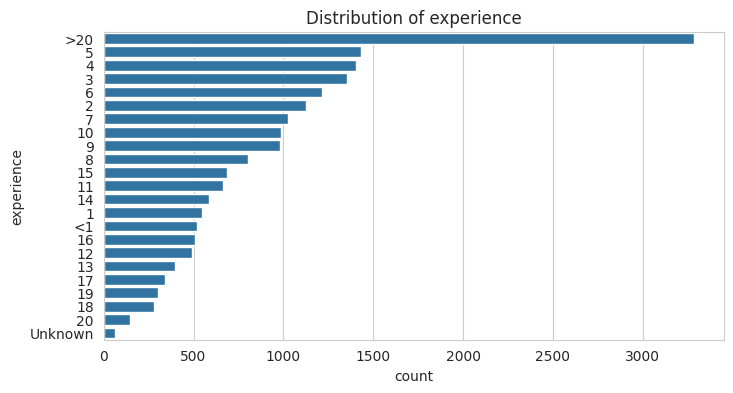

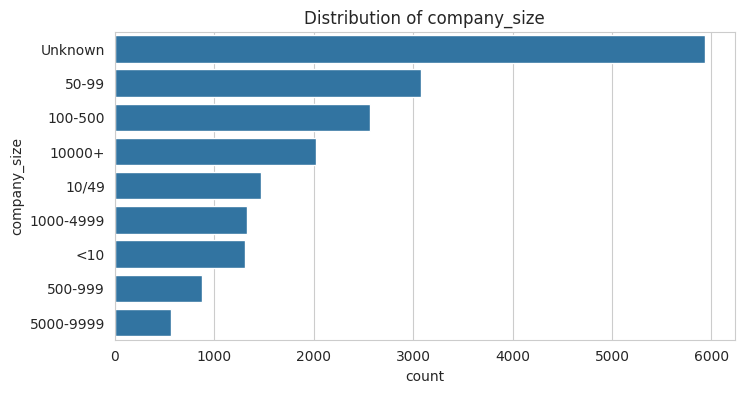

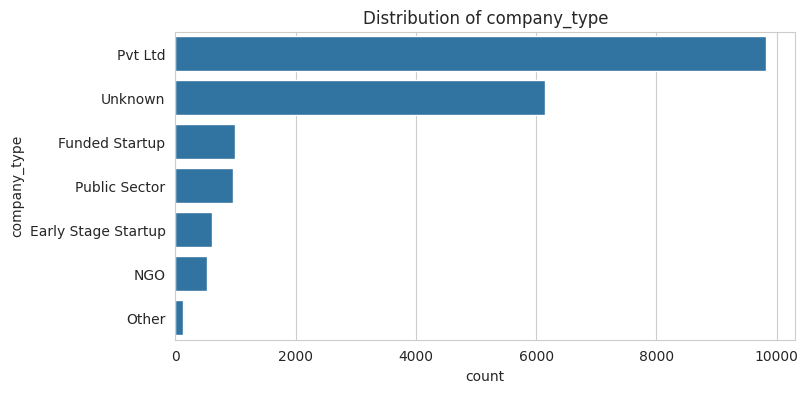

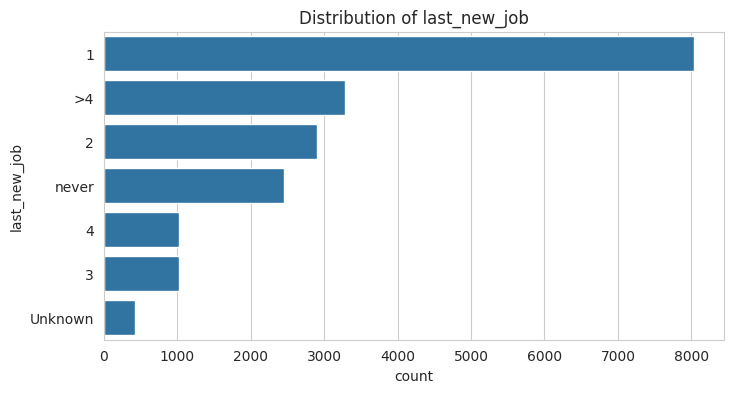

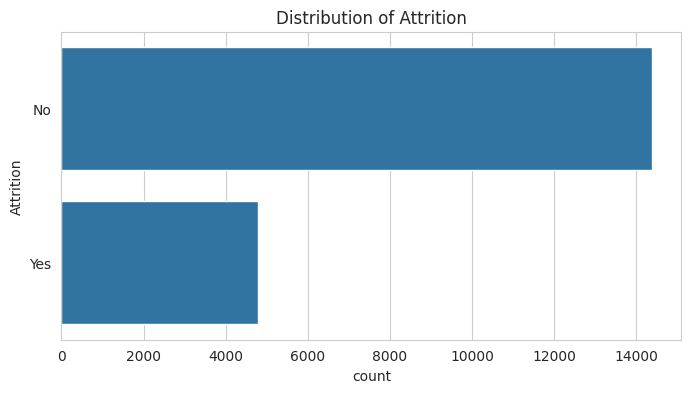

In [31]:
# Count of categories for every categorical feature
for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col,data=df,order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

## 6. How Each Feature Relates to Attrition

Here we compare leavers and stayers across the most important numeric features using box-plots.

**A numeric feature vs Attrition** — how a key numeric feature differs between stayers and leavers.

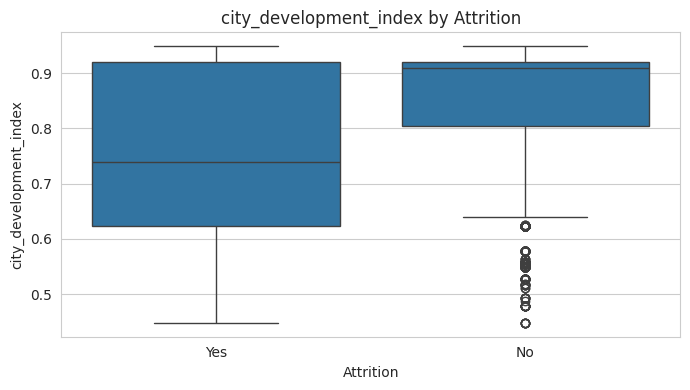

In [32]:
# A numeric feature for stayers vs leavers
_num = numerical_features[0]
plt.figure(figsize=(7, 4)); sns.boxplot(x='Attrition', y=_num, data=df)
plt.title(f'{_num} by Attrition'); plt.tight_layout(); plt.show()


**A numeric feature vs Attrition** — how a key numeric feature differs between stayers and leavers.

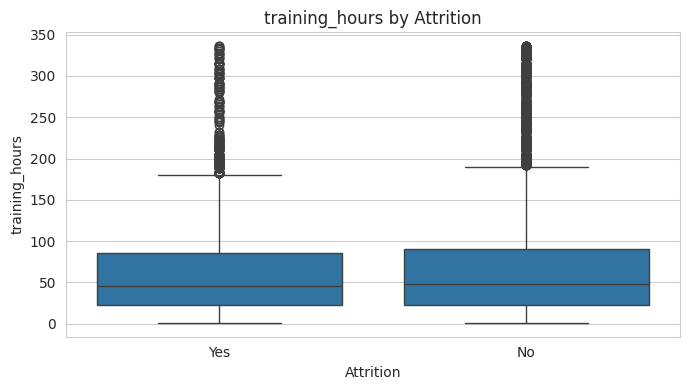

In [33]:
# Another numeric feature for stayers vs leavers
_num = numerical_features[-1]
plt.figure(figsize=(7, 4)); sns.boxplot(x='Attrition', y=_num, data=df)
plt.title(f'{_num} by Attrition'); plt.tight_layout(); plt.show()


**A numeric feature vs Attrition** — how a key numeric feature differs between stayers and leavers.

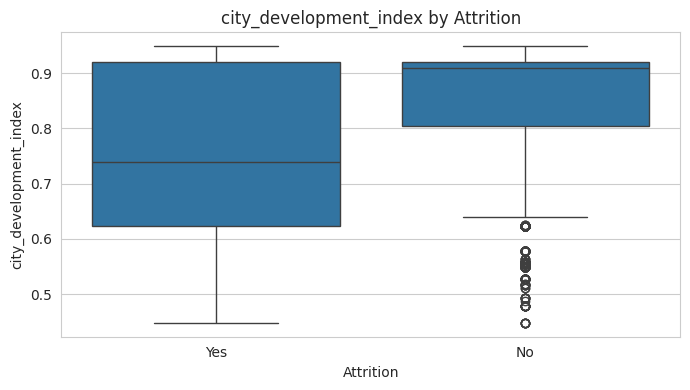

In [34]:
# A numeric feature for stayers vs leavers
_num = numerical_features[0]
plt.figure(figsize=(7,4)); sns.boxplot(x='Attrition', y=_num, data=df)
plt.title(f'{_num} by Attrition'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

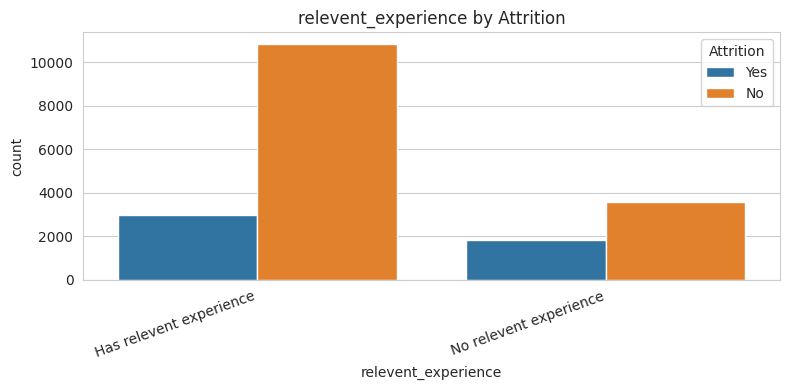

In [35]:
# A categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[min(0, len(_cats)-1)]
plt.figure(figsize=(8, 4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

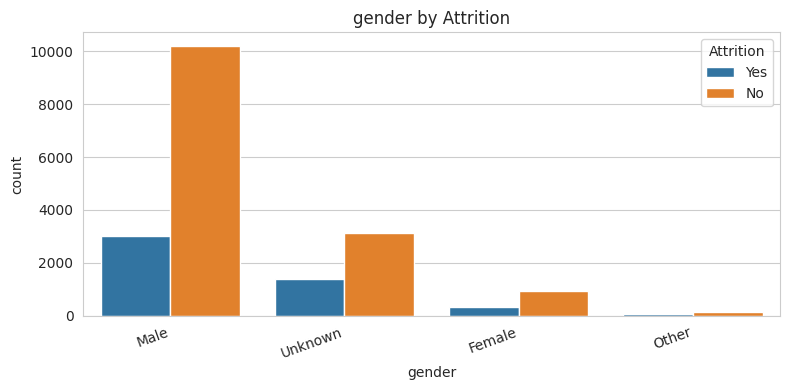

In [36]:
# A categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[min(1, len(_cats)-1)]
plt.figure(figsize=(8, 4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

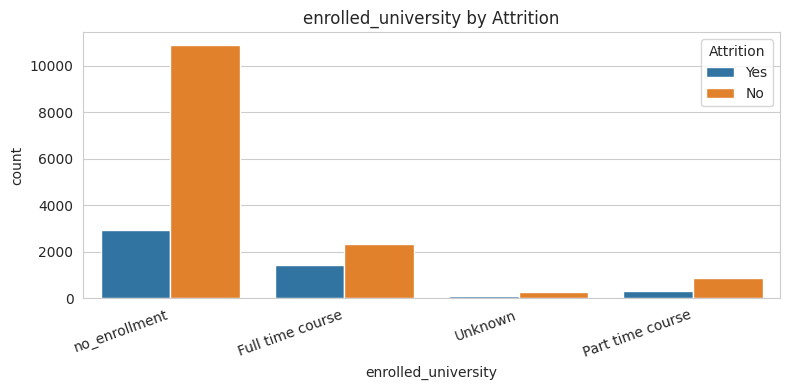

In [37]:
# A categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[min(2, len(_cats)-1)]
plt.figure(figsize=(8, 4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

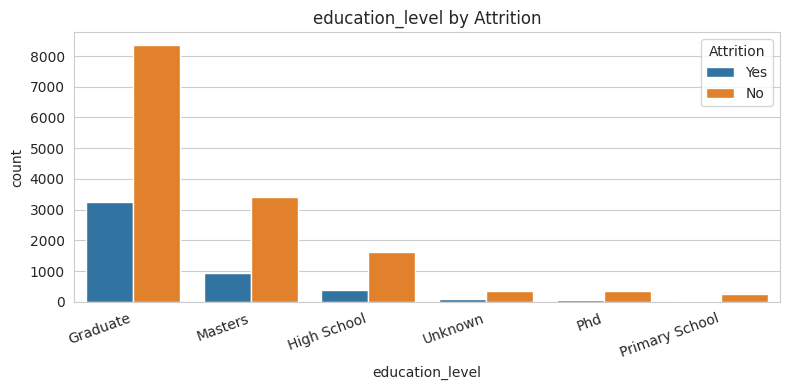

In [38]:
# A categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[min(3, len(_cats)-1)]
plt.figure(figsize=(8, 4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A numeric feature vs Attrition** — how a key numeric feature differs between stayers and leavers.

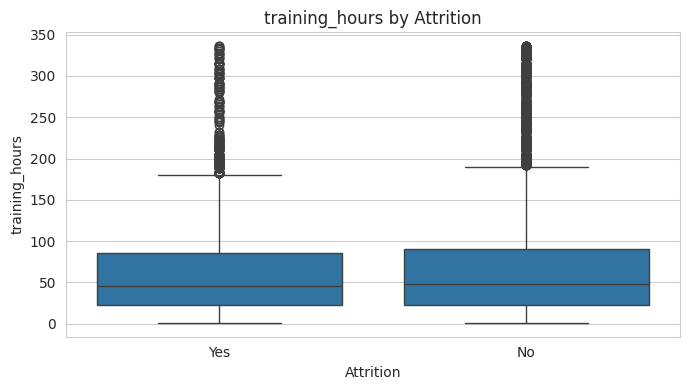

In [39]:
# Another numeric feature for stayers vs leavers
_num2 = numerical_features[-1]
plt.figure(figsize=(7,4)); sns.boxplot(x='Attrition', y=_num2, data=df)
plt.title(f'{_num2} by Attrition'); plt.tight_layout(); plt.show()


## 7. Which Categories Show the Most Attrition

We split each key categorical feature by attrition to see which groups leave more often.

**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

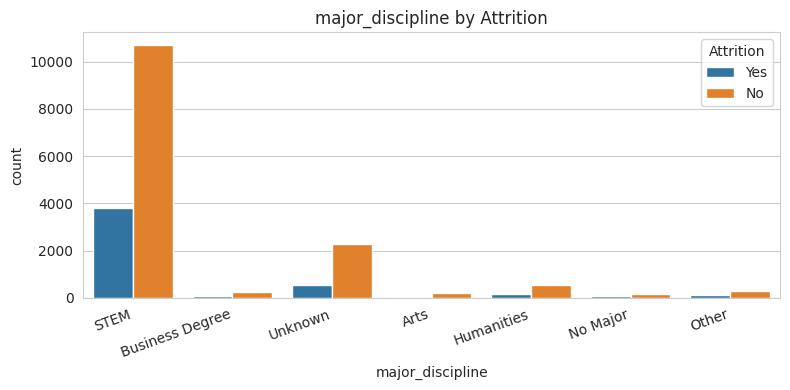

In [40]:
# A categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[min(4, len(_cats)-1)]
plt.figure(figsize=(8, 4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

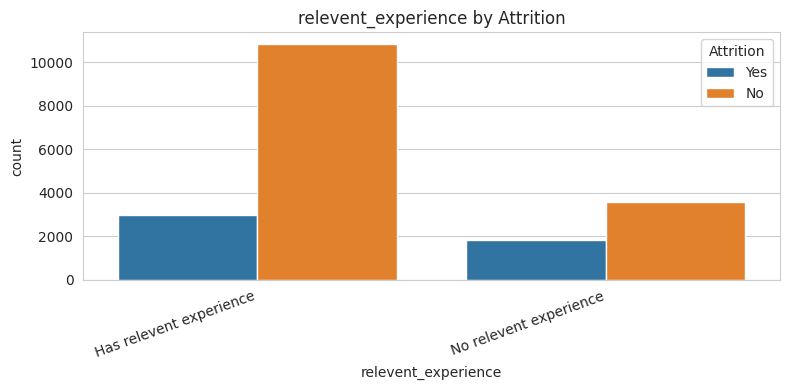

In [41]:
# A categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[0]
plt.figure(figsize=(8,4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

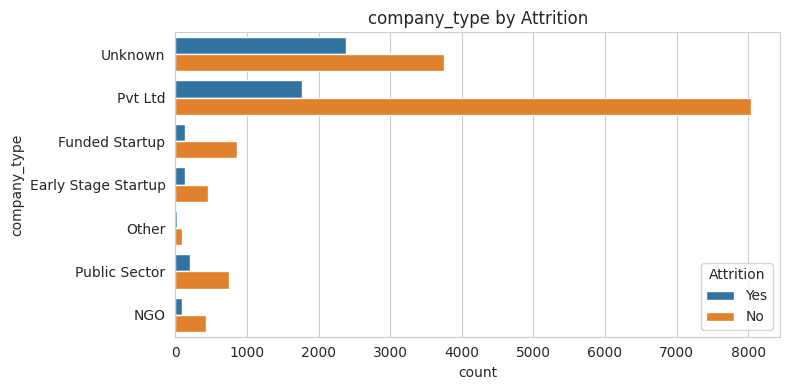

In [42]:
# A categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[min(5, len(_cats)-1)]
plt.figure(figsize=(8, 4)); sns.countplot(y=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

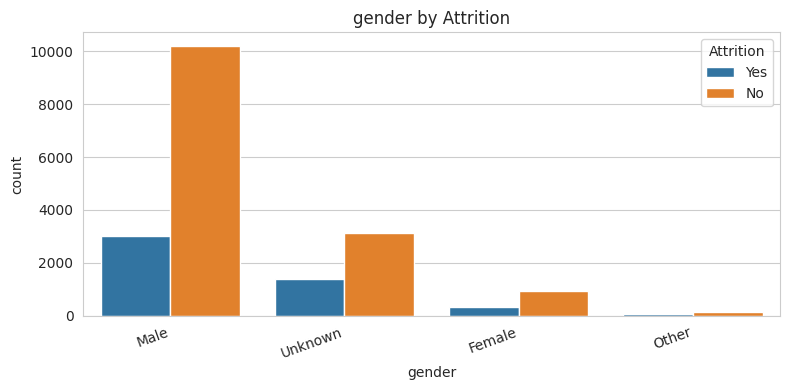

In [43]:
# A second categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[1] if len(_cats) > 1 else _cats[0]
plt.figure(figsize=(8,4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

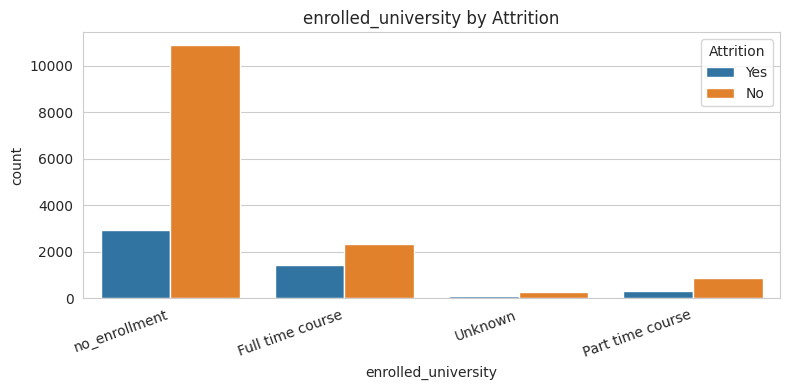

In [44]:
# A third categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[2] if len(_cats) > 2 else _cats[-1]
plt.figure(figsize=(8,4)); sns.countplot(x=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()


**A categorical feature vs Attrition** — attrition split across the categories of a key feature.

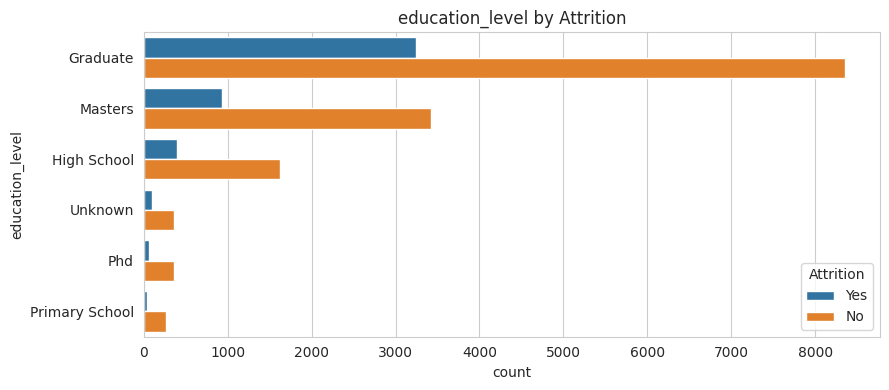

In [45]:
# A fourth categorical feature split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_cat = _cats[3] if len(_cats) > 3 else _cats[-1]
plt.figure(figsize=(9,4)); sns.countplot(y=_cat, hue='Attrition', data=df)
plt.title(f'{_cat} by Attrition'); plt.tight_layout(); plt.show()


## 8. Looking at Several Features Together

A correlation heatmap, the features most related to income, a pairplot, and three-way
breakdowns that combine two categories with attrition.

**Correlation heatmap**

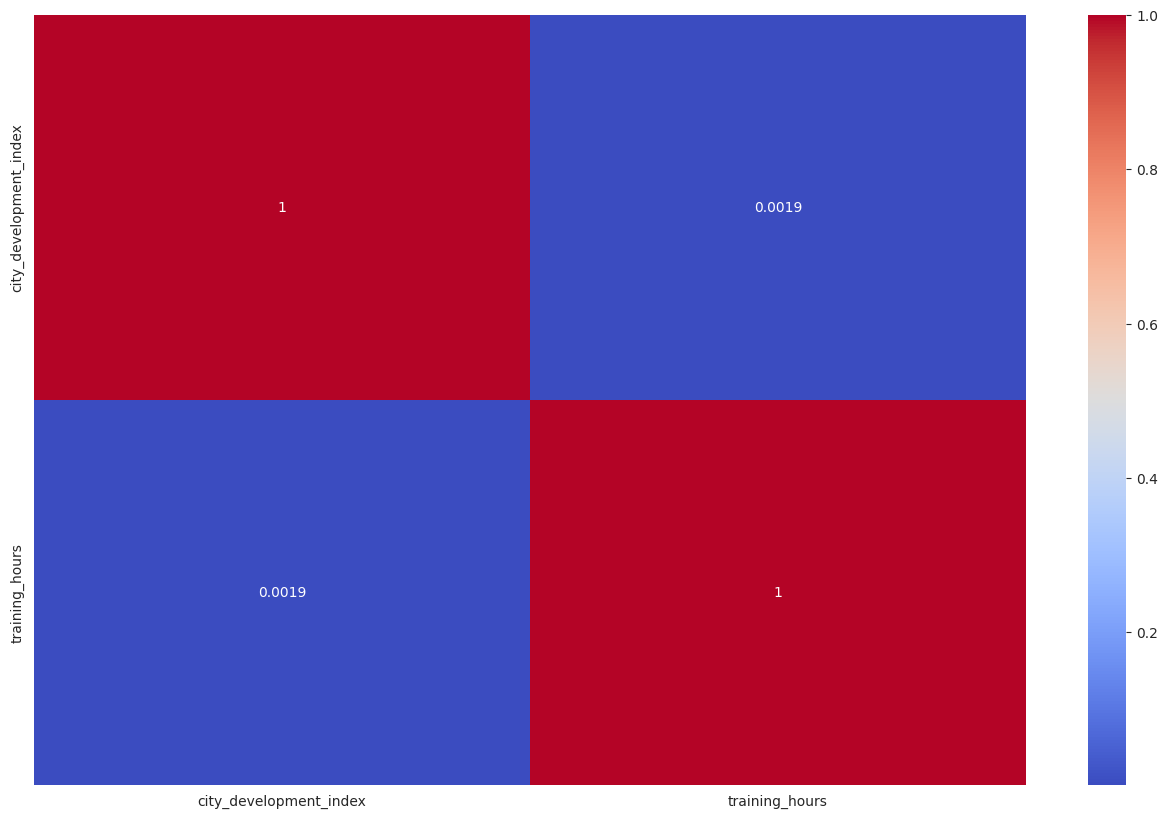

In [46]:
# Heatmap of correlations between numeric features
plt.figure(figsize=(16,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Features most correlated with a numeric feature.**

In [47]:
# Features ranked by correlation with a numeric feature
corr = df.corr(numeric_only=True)
_ref = numerical_features[0]
corr[_ref].sort_values(ascending=False)


city_development_index    1.00000
training_hours            0.00192
Name: city_development_index, dtype: float64

**Pairplot** of a few key features, coloured by attrition.

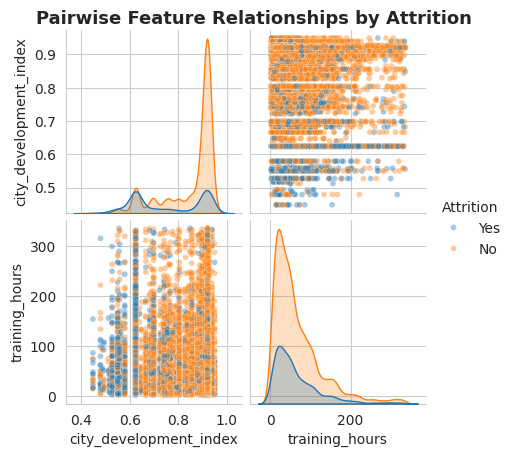

In [48]:
# Pairwise scatter of key numeric features, coloured by attrition
selected = numerical_features[:4]
g = sns.pairplot(df[selected + ['Attrition']], hue='Attrition',
                 height=2.2, plot_kws={'alpha': 0.4, 's': 18})
g.fig.suptitle('Pairwise Feature Relationships by Attrition', y=1.02,
               fontsize=13, fontweight='bold')
plt.show()


**Two categorical features vs Attrition** — attrition across two categorical features together.

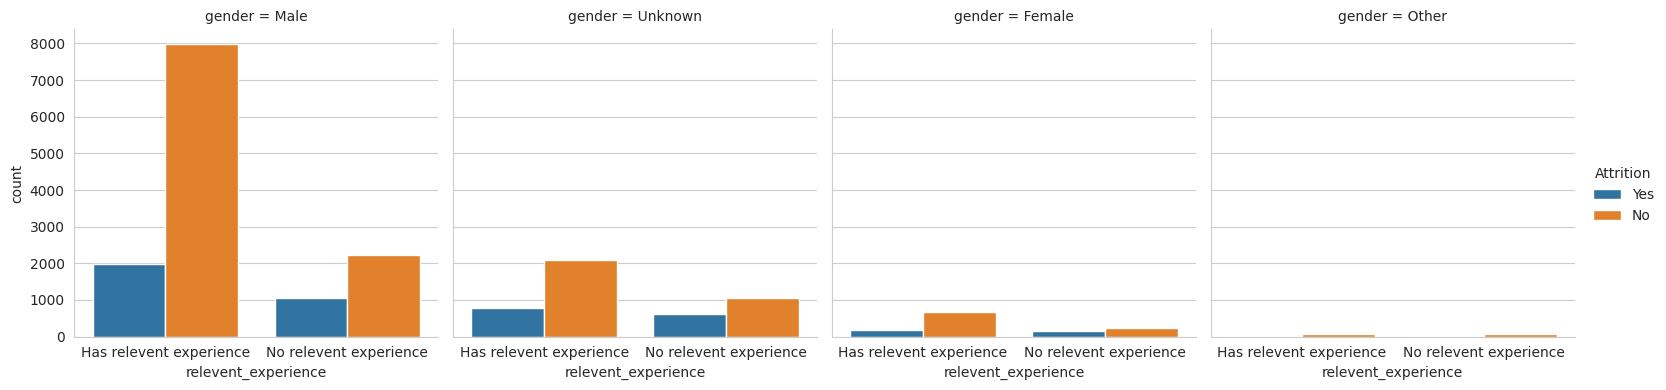

In [49]:
# Two categorical features together, split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_x, _col = _cats[min(0, len(_cats)-1)], _cats[min(1, len(_cats)-1)]
sns.catplot(x=_x, hue='Attrition', col=_col, kind='count', data=df, height=4)
plt.show()


**Two categorical features vs Attrition** — attrition across two categorical features together.

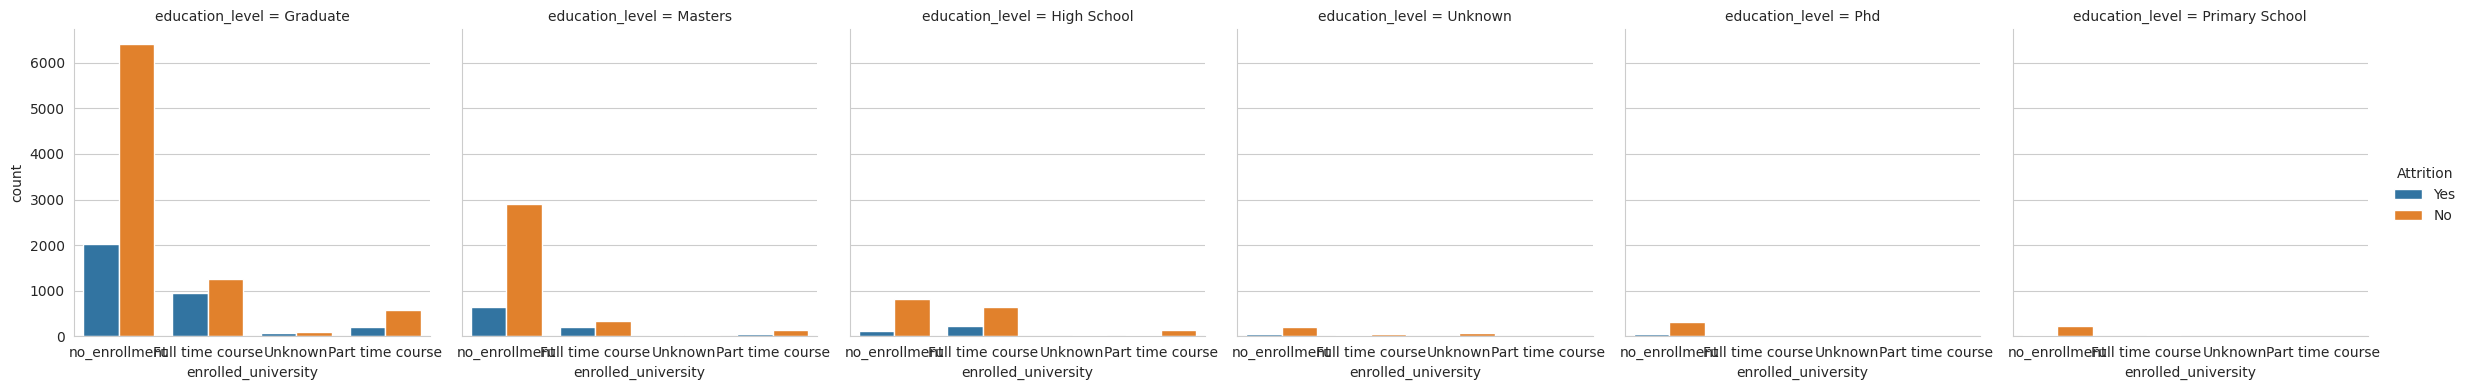

In [50]:
# Two categorical features together, split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_x, _col = _cats[min(2, len(_cats)-1)], _cats[min(3, len(_cats)-1)]
sns.catplot(x=_x, hue='Attrition', col=_col, kind='count', data=df, height=4)
plt.show()


**Two categorical features vs Attrition** — attrition across two categorical features together.

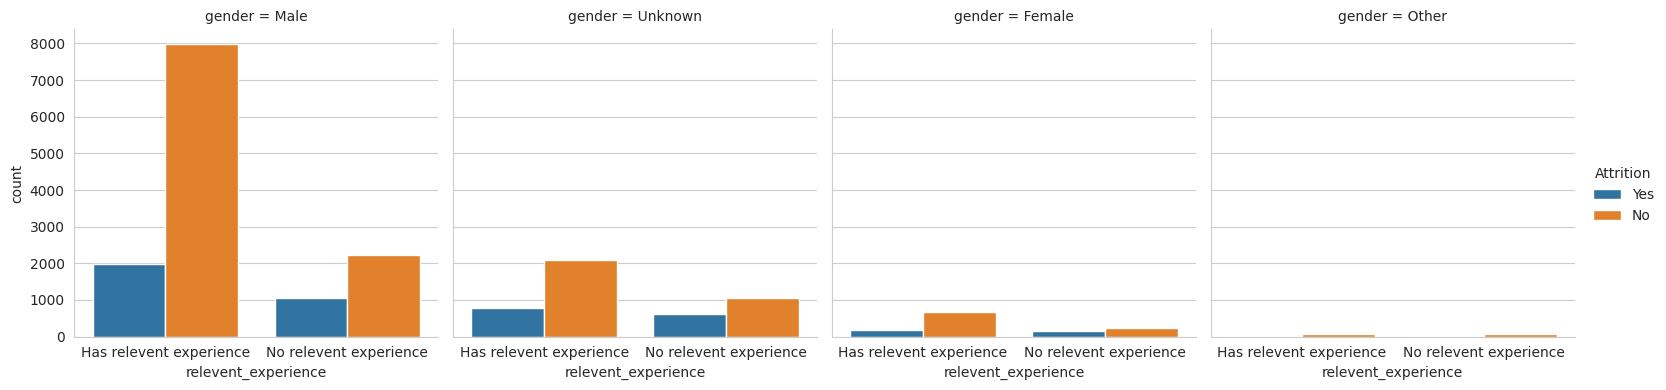

In [51]:
# Two low-cardinality categorical features together, split by attrition
_cats = sorted([c for c in categorical_features if c != 'Attrition'], key=lambda c: df[c].nunique())
_x, _col = _cats[0], (_cats[1] if len(_cats) > 1 else _cats[0])
sns.catplot(x=_x, hue='Attrition', col=_col, kind='count', data=df, height=4)
plt.show()


## 9. Missing Values, Duplicates and Outliers

A final data-quality check before modelling. We confirm there are no missing values or
duplicates, then count outliers in the main numeric columns using the IQR rule.

**Missing values check**

In [52]:
# Confirm there are no missing values left
df.isnull().sum()

city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
Attrition                 0
dtype: int64

**Duplicate rows check**

In [53]:
# Confirm there are no duplicate rows
df.duplicated().sum()

np.int64(49)

**Columns to check for outliers**

In [54]:
# Numeric columns to inspect for outliers
outlier_cols = numerical_features[:5]
print(outlier_cols)


['city_development_index', 'training_hours']


**IQR rule** for finding outliers.

In [55]:
# A value is an outlier if it falls outside 1.5 x IQR from the quartiles
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

**Count of outliers per column**

In [56]:
# Number of outliers in each selected column
for col in outlier_cols:

    outliers = detect_outliers_iqr(df,col)

    print(col, len(outliers))

city_development_index 17
training_hours 984


## 10. Statistical Tests Against Attrition

We test which features are statistically linked to attrition. Numeric features use a
two-sample t-test (leavers vs stayers); categorical features use a chi-square test. A small
p-value (below 0.05) means the feature is significantly related to attrition.

**Separate numeric and categorical columns for the tests**

In [57]:
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['training_hours'], dtype='object')
Categorical Columns: Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'education_level', 'major_discipline', 'experience', 'company_size',
       'company_type', 'last_new_job', 'Attrition'],
      dtype='object')


**T-test** for numeric features.

In [58]:
from scipy.stats import ttest_ind

for col in num_cols:
    yes = df[df['Attrition']=='Yes'][col]
    no = df[df['Attrition']=='No'][col]

    stat, p = ttest_ind(yes, no)

    print(f"\nColumn: {col}")
    print("P-value:", round(p,4))

    if p < 0.05:
        print("Reject H0 → Significant relationship with Attrition")
    else:
        print("Fail to Reject H0 → No significant relationship")


Column: training_hours
P-value: 0.0028
Reject H0 → Significant relationship with Attrition


**Chi-square test** for categorical features.

In [59]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    
    if col != 'Attrition':
        
        table = pd.crosstab(df[col], df['Attrition'])

        chi2, p, dof, exp = chi2_contingency(table)

        print(f"\nColumn: {col}")
        print("P-value:", round(p,4))

        if p < 0.05:
            print("Reject H0 → Significant relationship")
        else:
            print("Fail to Reject H0 → No significant relationship")


Column: city
P-value: 0.0
Reject H0 → Significant relationship

Column: gender
P-value: 0.0
Reject H0 → Significant relationship

Column: relevent_experience
P-value: 0.0
Reject H0 → Significant relationship

Column: enrolled_university
P-value: 0.0
Reject H0 → Significant relationship

Column: education_level
P-value: 0.0
Reject H0 → Significant relationship

Column: major_discipline
P-value: 0.0
Reject H0 → Significant relationship

Column: experience
P-value: 0.0
Reject H0 → Significant relationship

Column: company_size
P-value: 0.0
Reject H0 → Significant relationship

Column: company_type
P-value: 0.0
Reject H0 → Significant relationship

Column: last_new_job
P-value: 0.0
Reject H0 → Significant relationship


**Summary table** of every feature, its p-value and the decision.

In [60]:
from scipy.stats import ttest_ind, chi2_contingency
import pandas as pd

results = []

for col in df.columns:
    
    if col == 'Attrition':
        continue

    if df[col].dtype == 'object':

        table = pd.crosstab(df[col], df['Attrition'])

        stat, p, dof, exp = chi2_contingency(table)

    else:

        yes = df[df['Attrition']=='Yes'][col]
        no = df[df['Attrition']=='No'][col]

        stat, p = ttest_ind(yes, no)

    decision = "Reject H0" if p < 0.05 else "Fail to Reject H0"

    results.append([col, round(p,4), decision])

summary = pd.DataFrame(
results,
columns=['Feature','P_Value','Decision']
)

print(summary.sort_values('P_Value'))

                   Feature  P_Value   Decision
0                     city   0.0000  Reject H0
1   city_development_index   0.0000  Reject H0
2                   gender   0.0000  Reject H0
3      relevent_experience   0.0000  Reject H0
4      enrolled_university   0.0000  Reject H0
5          education_level   0.0000  Reject H0
6         major_discipline   0.0000  Reject H0
7               experience   0.0000  Reject H0
8             company_size   0.0000  Reject H0
9             company_type   0.0000  Reject H0
10            last_new_job   0.0000  Reject H0
11          training_hours   0.0028  Reject H0


## 11. Prepare the Data for Modelling

Now we get the data model-ready: turn the target into 0/1, convert categorical text into
numbers, split into features and target, make a stratified train/validation/test split (validation is used for early stopping; the test set is held out until final evaluation), and scale the
features so every column is on the same range.

**Encode the target** (Yes -> 1, No -> 0).

In [61]:
# Make a modelling copy and turn the target into 1 (Left) / 0 (Stayed)
df_model = df.copy()
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})
print(df_model['Attrition'].value_counts())
print("1 = Left | 0 = Stayed")

Attrition
0    14381
1     4777
Name: count, dtype: int64
1 = Left | 0 = Stayed


**Remove any leftover constant/ID columns** (safe even if already dropped above).

In [62]:
# Drop any constant/identifier columns still present
const_cols = [c for c in df_model.columns if df_model[c].nunique(dropna=False) <= 1]
id_cols    = [c for c in df_model.columns
              if c.lower().endswith('id')
              or (df_model[c].dtype == 'object' and df_model[c].nunique() == len(df_model))]
df_model.drop(columns=[c for c in dict.fromkeys(const_cols + id_cols) if c in df_model.columns],
              inplace=True)
print("Shape after dropping:", df_model.shape)


Shape after dropping: (19158, 13)


**Label-encode** the categorical columns.

In [63]:
# Convert every categorical column into numbers
encoder = LabelEncoder()
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    df_model[col] = encoder.fit_transform(df_model[col])
print("Encoded columns:", categorical_cols)

Encoded columns: ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


**Split into features (X) and target (y).**

In [64]:
# Features and target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']
print("Features:", X.shape, "| Target:", y.shape)

Features: (19158, 12) | Target: (19158,)


### 11b. Train on Significant Features Only

Flip the switch below to train the models on **only the statistically significant features** (p < 0.05 from the t-test / chi-square tests in Section 10), or on all features. Significance is recomputed here so this cell is self-contained.

In [65]:
# ================================================================
#   SIGNIFICANT-FEATURE SWITCH
#   True  -> train ONLY on statistically significant features (p < alpha)
#   False -> train on ALL features
# ================================================================
USE_SIGNIFICANT_ONLY = True          # <-- flip this switch (True / False)
SIGNIFICANCE_ALPHA   = 0.05

from scipy.stats import ttest_ind, chi2_contingency

# Binary target from the raw Attrition column (handles Yes/No, True/False, 1/0)
_att = df['Attrition']
if _att.dtype == bool:
    _y_sig = _att.astype(int)
else:
    _y_sig = (_att.astype(str).str.strip().str.lower()
              .map({'yes':1,'no':0,'true':1,'false':0,'1':1,'0':0,
                    'left':1,'stayed':0,'stay':0}))

def _feature_pvalue(col):
    """p-value of one feature vs Attrition (t-test numeric, chi-square categorical)."""
    try:
        s = df[col] if col in df.columns else df_model[col]
        if s.dtype == 'object' or str(s.dtype) == 'bool':
            table = pd.crosstab(s, _y_sig)
            _, p, _, _ = chi2_contingency(table)
        else:
            a = s[_y_sig == 1]; b = s[_y_sig == 0]
            _, p = ttest_ind(a, b)
        return float(p)
    except Exception:
        return 1.0

pvals = {c: _feature_pvalue(c) for c in X.columns}
significant_features = [c for c, pv in pvals.items()
                        if np.isfinite(pv) and pv < SIGNIFICANCE_ALPHA]
dropped_features     = [c for c in X.columns if c not in significant_features]

print(f"Significance level (alpha) : {SIGNIFICANCE_ALPHA}")
print(f"Significant features       : {len(significant_features)} / {X.shape[1]}")

if USE_SIGNIFICANT_ONLY and len(significant_features) > 0:
    X = X[significant_features].copy()
    print("\n\u2705 Training on SIGNIFICANT features only.")
    print("   Kept    :", significant_features)
    print("   Dropped :", dropped_features)
else:
    print("\n\u2139\ufe0f  Training on ALL features.")

print(f"\nFinal feature matrix X : {X.shape}")


Significance level (alpha) : 0.05
Significant features       : 12 / 12

✅ Training on SIGNIFICANT features only.
   Kept    : ['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']
   Dropped : []

Final feature matrix X : (19158, 12)


**Train/test split** — 80% train, 20% test, keeping the class balance.

In [66]:
# Genuine three-way split: 80% train / 10% validation / 10% test, stratified.
# Step 1: hold out 20% (this becomes validation + test).
# Step 2: split that 20% evenly into a VALIDATION set (for early stopping)
#         and a TEST set (untouched until final evaluation).
# This keeps the training set as large as the reference pipeline (80%) while
# still providing a real, separate validation set and a real, held-out test set.
X_trainfull, X_temp, y_trainfull, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)
X_train, y_train = X_trainfull, y_trainfull

print("Training rows  :", X_train.shape[0])
print("Validation rows:", X_val.shape[0])
print("Test rows      :", X_test.shape[0])


Training rows  : 15326
Validation rows: 1916
Test rows      : 1916


**Scale the features** with StandardScaler.

In [67]:
# Fit the scaler on the TRAINING data only, then apply it to all three sets.
# Fitting only on training data is what keeps validation/test truly held-out.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("Scaled shapes -> train:", X_train_scaled.shape,
      "| val:", X_val_scaled.shape, "| test:", X_test_scaled.shape)

Scaled shapes -> train: (15326, 12) | val: (1916, 12) | test: (1916, 12)


## 12. Balance the Classes

Far more employees stay than leave. To help the model learn the smaller "leave" class, we add
slightly noised copies of the minority-class training rows. This is done on the training set
only, so no test information leaks in.

In [68]:
# No tabular augmentation — train on the raw (imbalanced) training set,
# matching the reference pipeline.
X_train_scaled = X_train_scaled.astype(np.float32)
y_train        = y_train.reset_index(drop=True)

print("No augmentation applied (matching reference pipeline).")
print(f"   X_train_scaled shape : {X_train_scaled.shape}")
print(f"   Class balance        : {dict(zip(*np.unique(y_train, return_counts=True)))}")


No augmentation applied (matching reference pipeline).
   X_train_scaled shape : (15326, 12)
   Class balance        : {np.int64(0): np.int64(11504), np.int64(1): np.int64(3822)}


## 13. Build Tensors and DataLoaders

We convert the prepared arrays into PyTorch tensors and wrap them in DataLoaders that feed the
model in mini-batches.

In [69]:
# Converting NumPy Arrays to PyTorch Tensors
def make_tensor(arr, dtype=torch.float32):
    """Deterministic tensor creation — no hidden randomness."""
    return torch.tensor(arr, dtype=dtype)

X_train_tensor = make_tensor(X_train_scaled)
X_val_tensor   = make_tensor(X_val_scaled)
X_test_tensor  = make_tensor(X_test_scaled)
y_train_tensor = make_tensor(y_train.values).view(-1, 1)
y_val_tensor   = make_tensor(y_val.values).view(-1, 1)
y_test_tensor  = make_tensor(y_test.values).view(-1, 1)

print("✅ Tensors created!")
print(f"   X_train_tensor : {tuple(X_train_tensor.shape)}")
print(f"   X_val_tensor   : {tuple(X_val_tensor.shape)}")
print(f"   X_test_tensor  : {tuple(X_test_tensor.shape)}")

✅ Tensors created!
   X_train_tensor : (15326, 12)
   X_val_tensor   : (1916, 12)
   X_test_tensor  : (1916, 12)


In [70]:
# Creating Mini-Batch DataLoaders
# generator with fixed seed → same batch order every run
BATCH_SIZE = 200
g = torch.Generator(); g.manual_seed(SEED)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(TensorDataset(X_val_tensor,   y_val_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders ready! Batch size = {BATCH_SIZE}")
print(f"   Training batches   : {len(train_loader)}")
print(f"   Validation batches : {len(val_loader)}")
print(f"   Test batches       : {len(test_loader)}")

✅ DataLoaders ready! Batch size = 200
   Training batches   : 77
   Validation batches : 10
   Test batches       : 10


## 14. Model 1 — FT-Transformer

Our first attrition model is an FT-Transformer. It turns each feature into a small vector
(a token), lets the features attend to one another through transformer blocks, pools them with
attention, and finally classifies. The attention weights also let us explain its decisions.

**Feature tokenizer** — turns each scalar feature into a vector.

In [71]:
# Feature Tokenizer
class FeatureTokenizer(nn.Module):
    def __init__(self, num_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_features, d_token))
        self.bias   = nn.Parameter(torch.empty(num_features, d_token))
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        x = x.unsqueeze(-1)
        return x * self.weight + self.bias

print("✅ FeatureTokenizer defined.")

✅ FeatureTokenizer defined.


**Transformer block** — multi-head attention plus a feed-forward layer.

In [72]:
# Transformer Encoder Block
class TransformerBlock(nn.Module):
    def __init__(self, d_token, n_heads, dropout=0.2, ff_factor=4):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim=d_token, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.norm1 = nn.LayerNorm(d_token)
        self.norm2 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * ff_factor), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_token * ff_factor, d_token), nn.Dropout(dropout),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attention(
            x, x, x, need_weights=True, average_attn_weights=True
        )
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights

print("✅ TransformerBlock defined.")

✅ TransformerBlock defined.


**Attention pooling** — combines the feature tokens into one vector.

In [73]:
# Attention Pooling
class AttentionPooling(nn.Module):
    def __init__(self, d_token):
        super().__init__()
        self.attention_vector = nn.Linear(d_token, 1)

    def forward(self, x):
        scores  = self.attention_vector(x)
        weights = torch.softmax(scores, dim=1)
        pooled  = torch.sum(weights * x, dim=1)
        return pooled, weights

print("✅ AttentionPooling defined.")

✅ AttentionPooling defined.


**Full FT-Transformer** — tokenizer, transformer blocks, pooling and a classifier head.

In [74]:
# Full FT-Transformer
class AdvancedFTTransformer(nn.Module):
    def __init__(self, num_features, d_token=64, n_heads=8,
                 n_layers=4, dropout=0.3):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features, d_token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_token, n_heads, dropout) for _ in range(n_layers)
        ])
        self.pooling    = AttentionPooling(d_token)
        self.classifier = nn.Sequential(
            nn.Linear(d_token, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),     nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64),      nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
        self.attention_maps      = []
        self.pooling_attention   = None

    def forward(self, x):
        batch_size = x.shape[0]
        tokens = self.tokenizer(x)
        cls    = self.cls_token.expand(batch_size, -1, -1)
        x      = torch.cat([cls, tokens], dim=1)
        self.attention_maps = []
        for block in self.transformer_blocks:
            x, attn_weights = block(x)
            self.attention_maps.append(attn_weights.detach())
        pooled, pool_weights   = self.pooling(x)
        self.pooling_attention = pool_weights.detach().squeeze(-1)
        logits = self.classifier(pooled)
        return logits

print("✅ AdvancedFTTransformer defined.")

✅ AdvancedFTTransformer defined.


**Create the model, loss, optimiser and scheduler.**

In [75]:
# Initialise Model, Loss, Optimiser, Scheduler
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

num_features = X_train_tensor.shape[1]

# Re-seed before model init so weight init is deterministic
torch.manual_seed(SEED)

model_transformer = AdvancedFTTransformer(
    num_features=num_features,
    d_token=64, n_heads=8, n_layers=4, dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model_transformer.parameters() if p.requires_grad)
print(f"✅ Model ready — {total_params:,} trainable parameters")

criterion  = nn.BCEWithLogitsLoss()
optimizer  = torch.optim.AdamW(model_transformer.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

Using device: cpu
✅ Model ready — 260,354 trainable parameters


**Model summary** — layers and parameter counts.

In [76]:
# Advanced model summary (torchinfo)
try:
    from torchinfo import summary as torch_summary
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torchinfo"], check=False)
    from torchinfo import summary as torch_summary

# batch of 2 keeps BatchNorm valid during the summary forward pass
torch_summary(
    model_transformer,
    input_size=(2, num_features),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    depth=4,
    device=device,
    verbose=1,
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
AdvancedFTTransformer                    [2, 12]                   [2, 1]                    64                        True
├─FeatureTokenizer: 1-1                  [2, 12]                   [2, 12, 64]               1,536                     True
├─ModuleList: 1-2                        --                        --                        --                        True
│    └─TransformerBlock: 2-1             [2, 13, 64]               [2, 13, 64]               --                        True
│    │    └─MultiheadAttention: 3-1      [2, 13, 64]               [2, 13, 64]               16,640                    True
│    │    └─Dropout: 3-2                 [2, 13, 64]               [2, 13, 64]               --                        --
│    │    └─LayerNorm: 3-3               [2, 13, 64]               [2, 13, 64]               128                       True
│    

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
AdvancedFTTransformer                    [2, 12]                   [2, 1]                    64                        True
├─FeatureTokenizer: 1-1                  [2, 12]                   [2, 12, 64]               1,536                     True
├─ModuleList: 1-2                        --                        --                        --                        True
│    └─TransformerBlock: 2-1             [2, 13, 64]               [2, 13, 64]               --                        True
│    │    └─MultiheadAttention: 3-1      [2, 13, 64]               [2, 13, 64]               16,640                    True
│    │    └─Dropout: 3-2                 [2, 13, 64]               [2, 13, 64]               --                        --
│    │    └─LayerNorm: 3-3               [2, 13, 64]               [2, 13, 64]               128                       True
│    

## 15. Train and Evaluate the FT-Transformer

We train with early stopping (it keeps the best weights and stops when validation accuracy
stops improving), plot the learning curves, then evaluate on the held-out test set.

**Training loop with early stopping.**

In [77]:
# Training Loop with Early Stopping
EPOCHS       = 100
ES_PATIENCE  = 10        # stop after 10 epochs without improvement
ES_DELTA     = 1e-4      # minimum improvement considered meaningful

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc   = 0.0
best_epoch     = 0
epochs_no_impr = 0
best_state     = None        # stores best model weights

print(f"Training for up to {EPOCHS} epochs (early-stop patience={ES_PATIENCE}) on {device}...")

for epoch in range(EPOCHS):
    # ── Train ──
    model_transformer.train()
    run_loss, run_correct, run_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model_transformer(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        run_loss    += loss.item()
        preds        = (torch.sigmoid(logits) >= 0.5).float()
        run_correct += (preds == y_batch).sum().item()
        run_total   += y_batch.size(0)

    train_loss = run_loss / len(train_loader)
    train_acc  = run_correct / run_total

    # ── Validate ──
    model_transformer.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits   = model_transformer(X_batch)
            v_loss  += criterion(logits, y_batch).item()
            preds    = (torch.sigmoid(logits) >= 0.5).float()
            v_correct += (preds == y_batch).sum().item()
            v_total   += y_batch.size(0)

    val_loss = v_loss / len(val_loader)
    val_acc  = v_correct / v_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] "
              f"train_loss={train_loss:.4f} acc={train_acc*100:5.1f}% | "
              f"val_loss={val_loss:.4f} acc={val_acc*100:5.1f}%")

    # ── Early stopping check ──
    if val_acc > best_val_acc + ES_DELTA:
        best_val_acc   = val_acc
        best_epoch     = epoch + 1
        epochs_no_impr = 0
        import copy
        best_state = copy.deepcopy(model_transformer.state_dict())
    else:
        epochs_no_impr += 1
        if epochs_no_impr >= ES_PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch+1}. "
                  f"Best val acc = {best_val_acc*100:.2f}% (epoch {best_epoch})")
            break

# Restore best weights
if best_state is not None:
    model_transformer.load_state_dict(best_state)
    print(f"\n✅ Best weights restored from epoch {best_epoch}")

print(f"✅ Training complete — best validation accuracy: {best_val_acc*100:.2f}%")

Training for up to 100 epochs (early-stop patience=10) on cpu...
Epoch [  1/100] train_loss=0.5403 acc= 73.7% | val_loss=0.4784 acc= 75.7%
Epoch [ 10/100] train_loss=0.4487 acc= 78.5% | val_loss=0.4431 acc= 78.9%
Epoch [ 20/100] train_loss=0.4438 acc= 79.1% | val_loss=0.4414 acc= 78.7%

⏹ Early stopping at epoch 21. Best val acc = 80.06% (epoch 11)

✅ Best weights restored from epoch 11
✅ Training complete — best validation accuracy: 80.06%


**Learning curves** — loss and accuracy over epochs.

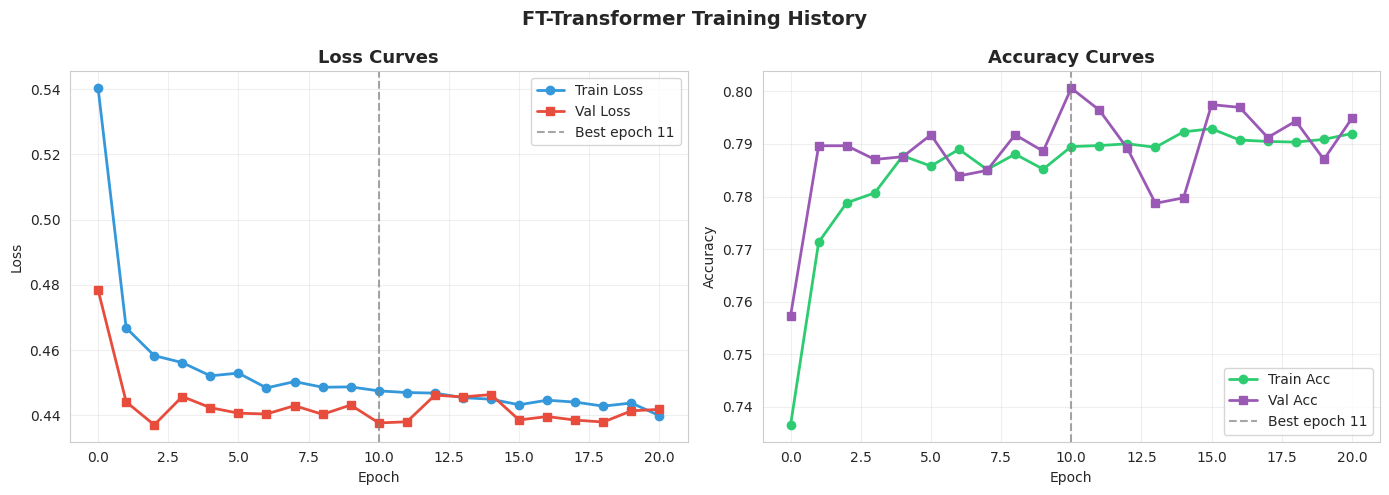

In [78]:
# Training History Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], 'o-', label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history["val_loss"],   's-', label='Val Loss',   color='#e74c3c', linewidth=2)
if best_epoch:
    axes[0].axvline(best_epoch - 1, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch {best_epoch}')
axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], 'o-', label='Train Acc', color='#2ecc71', linewidth=2)
axes[1].plot(history["val_acc"],   's-', label='Val Acc',   color='#9b59b6', linewidth=2)
if best_epoch:
    axes[1].axvline(best_epoch - 1, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch {best_epoch}')
axes[1].set_title('Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('FT-Transformer Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Test-set evaluation** and confusion matrix.

Train      accuracy: 79.44%
Validation accuracy: 80.06%
Test       accuracy: 79.54%

              precision    recall  f1-score   support

        Stay       0.88      0.84      0.86      1439
       Leave       0.58      0.65      0.61       477

    accuracy                           0.80      1916
   macro avg       0.73      0.75      0.74      1916
weighted avg       0.81      0.80      0.80      1916



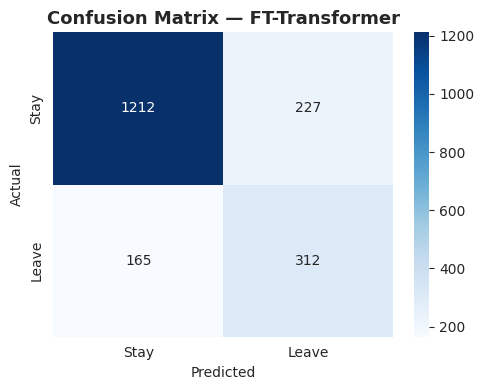

In [79]:
# Evaluation on ALL THREE splits: Train / Validation / Test
model_transformer.eval()

def _eval_loader(loader):
    preds, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model_transformer(X_batch.to(device))
            p = (torch.sigmoid(logits) >= 0.5).float().cpu().numpy().ravel()
            preds.extend(p); labels.extend(y_batch.numpy().ravel())
    labels = np.array(labels); preds = np.array(preds)
    return accuracy_score(labels, preds), labels, preds

train_acc_final, _, _        = _eval_loader(train_loader)
val_acc_final,   _, _        = _eval_loader(val_loader)
transformer_acc, y_test_np, test_preds = _eval_loader(test_loader)

print(f"Train      accuracy: {train_acc_final*100:.2f}%")
print(f"Validation accuracy: {val_acc_final*100:.2f}%")
print(f"Test       accuracy: {transformer_acc*100:.2f}%\n")
print(classification_report(y_test_np, test_preds, target_names=['Stay', 'Leave']))

cm = confusion_matrix(y_test_np, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'], ax=ax)
ax.set_title('Confusion Matrix — FT-Transformer', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


## 16. What the Model Learns per Feature

The feature tokenizer is the first stage of the model: every feature becomes a learned vector
before any attention is applied. Here we look at those vectors for a few test employees.

In [80]:
# Feature extraction — per-feature token embeddings
# Each feature is turned into a learned vector before attention is applied.
model_transformer.eval()
with torch.no_grad():
    sample          = X_test_tensor[:3].to(device)
    token_features  = model_transformer.tokenizer(sample)   # (3, num_features, d_token)
    _               = model_transformer(sample)             # populates pooling_attention

print("Extracted token-feature tensor shape :", tuple(token_features.shape))
print("  (samples, features, d_token)")
print()
print("Sample 0 — feature 0 token vector (first 8 dims):")
print(" ", token_features[0, 0, :8].cpu().numpy().round(3))
print()
print("Sample 0 — pooling attention over [CLS]+features (rounded):")
print(" ", model_transformer.pooling_attention[0].cpu().numpy().round(3))

Extracted token-feature tensor shape : (3, 12, 64)
  (samples, features, d_token)

Sample 0 — feature 0 token vector (first 8 dims):
  [-0.186 -0.092  0.044 -0.269  0.052 -0.005  0.031 -0.174]

Sample 0 — pooling attention over [CLS]+features (rounded):
  [0.063 0.103 0.081 0.079 0.045 0.058 0.043 0.049 0.039 0.189 0.172 0.026
 0.053]


## 17. Explaining the FT-Transformer with Attention

Attention weights show which features the model paid attention to. We look at a single-sample
attention map, the average pooling weights across all test employees, the CLS-token attention
layer by layer, and an overall feature-importance ranking.

**Attention map for the first test employee (Layer 1).**

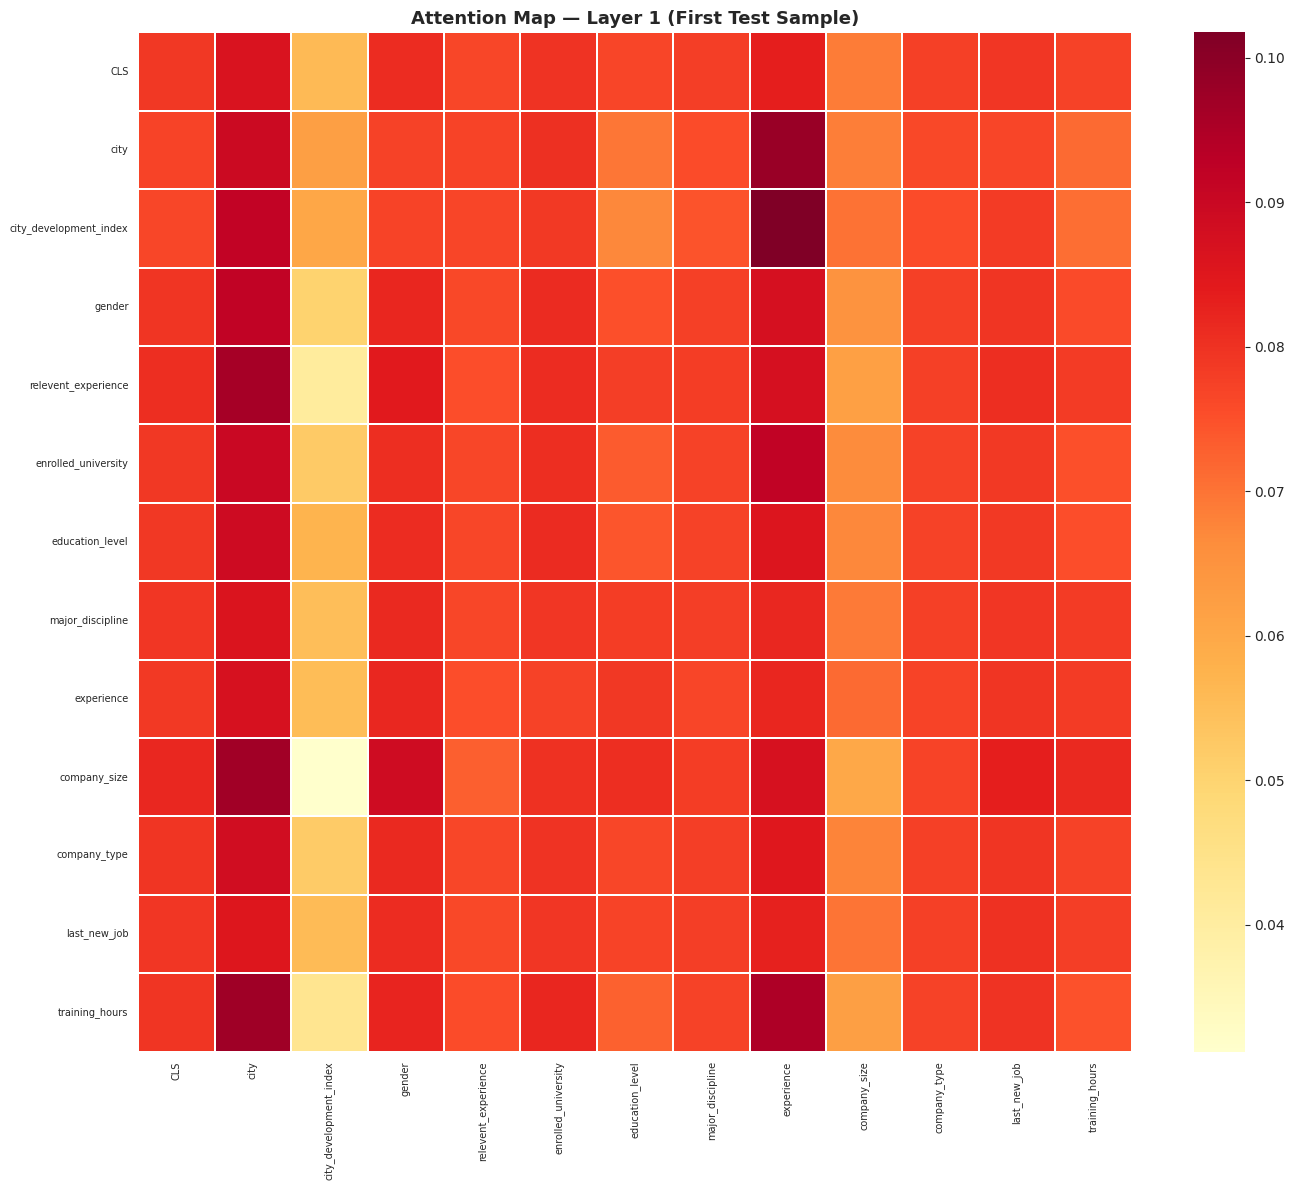

In [81]:
# Attention Weight Heatmap (Layer 1)
model_transformer.eval()
with torch.no_grad():
    _ = model_transformer(X_test_tensor[:1].to(device))

attn_map = model_transformer.attention_maps[0][0].cpu().numpy()
feature_labels = ['CLS'] + list(X.columns)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(attn_map, ax=ax, cmap='YlOrRd',
            xticklabels=feature_labels, yticklabels=feature_labels,
            linewidths=0.3)
ax.set_title('Attention Map — Layer 1 (First Test Sample)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout(); plt.show()

**Average pooling attention across all test employees.**

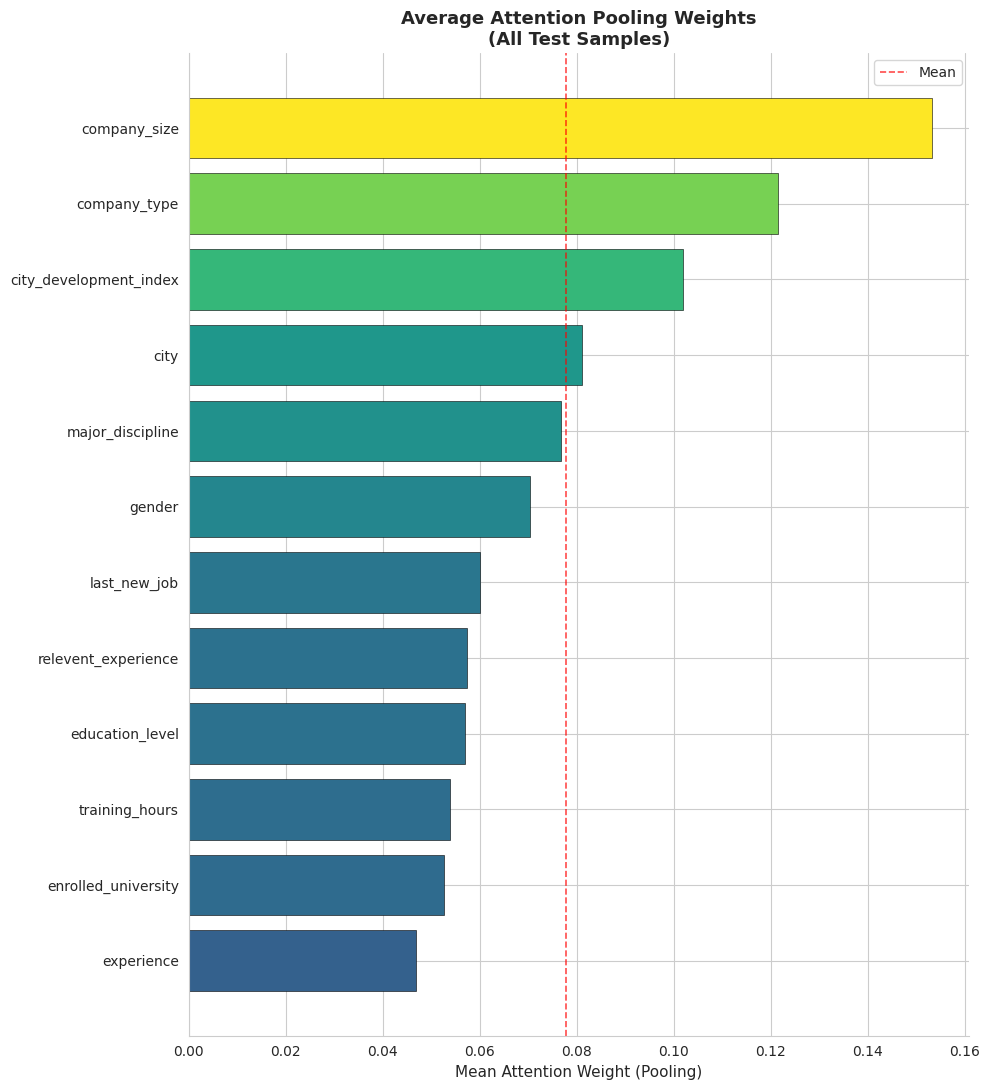

In [82]:
# Average Pooling Attention (All Test Samples)
model_transformer.eval()
with torch.no_grad():
    _ = model_transformer(X_test_tensor.to(device))

avg_pool = model_transformer.pooling_attention[:, 1:].mean(dim=0).cpu().numpy()
feat_names = np.array(list(X.columns))
order = np.argsort(avg_pool)

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(feat_names[order], avg_pool[order],
        color=plt.cm.viridis(avg_pool[order] / avg_pool.max()), edgecolor='black', linewidth=0.4)
ax.set_title('Average Attention Pooling Weights\n(All Test Samples)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Attention Weight (Pooling)', fontsize=11)
ax.axvline(avg_pool.mean(), color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Mean')
ax.legend(); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**CLS-token attention, layer by layer.**

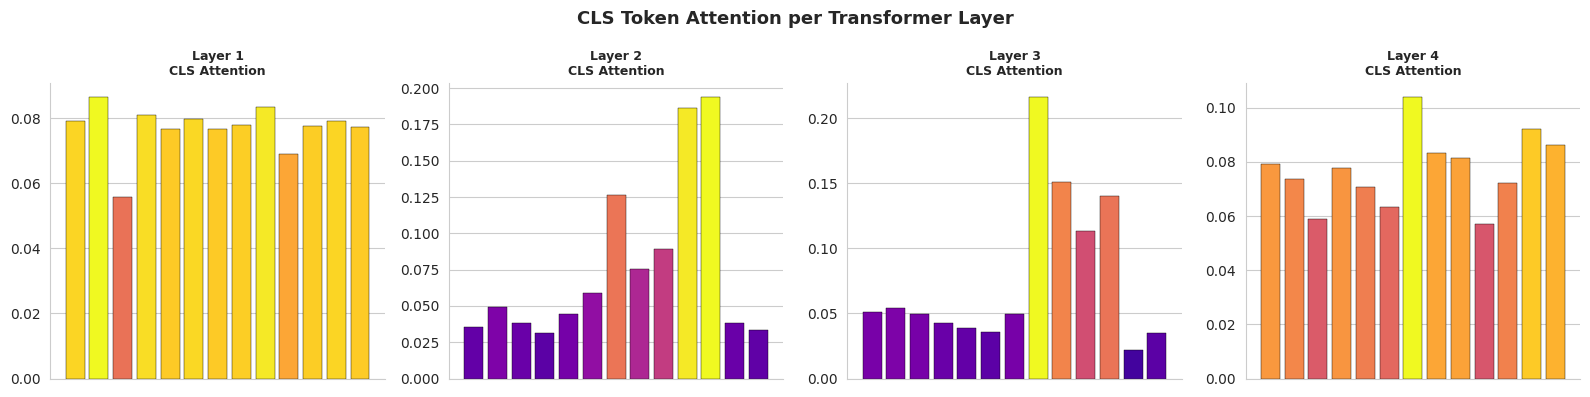

In [83]:
# Layer-by-Layer CLS Token Attention
model_transformer.eval()
with torch.no_grad():
    _ = model_transformer(X_test_tensor[:1].to(device))

fig, axes = plt.subplots(1, len(model_transformer.attention_maps), figsize=(16, 4))
feature_labels = ['CLS'] + list(X.columns)

for i, (attn, ax) in enumerate(zip(model_transformer.attention_maps, axes)):
    cls_attn = attn[0, 0, :].cpu().numpy()
    ax.bar(range(len(cls_attn)), cls_attn, color=plt.cm.plasma(cls_attn / cls_attn.max()),
           edgecolor='black', linewidth=0.3)
    ax.set_title(f'Layer {i+1}\nCLS Attention', fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('CLS Token Attention per Transformer Layer', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Feature importance from the last attention layer.**

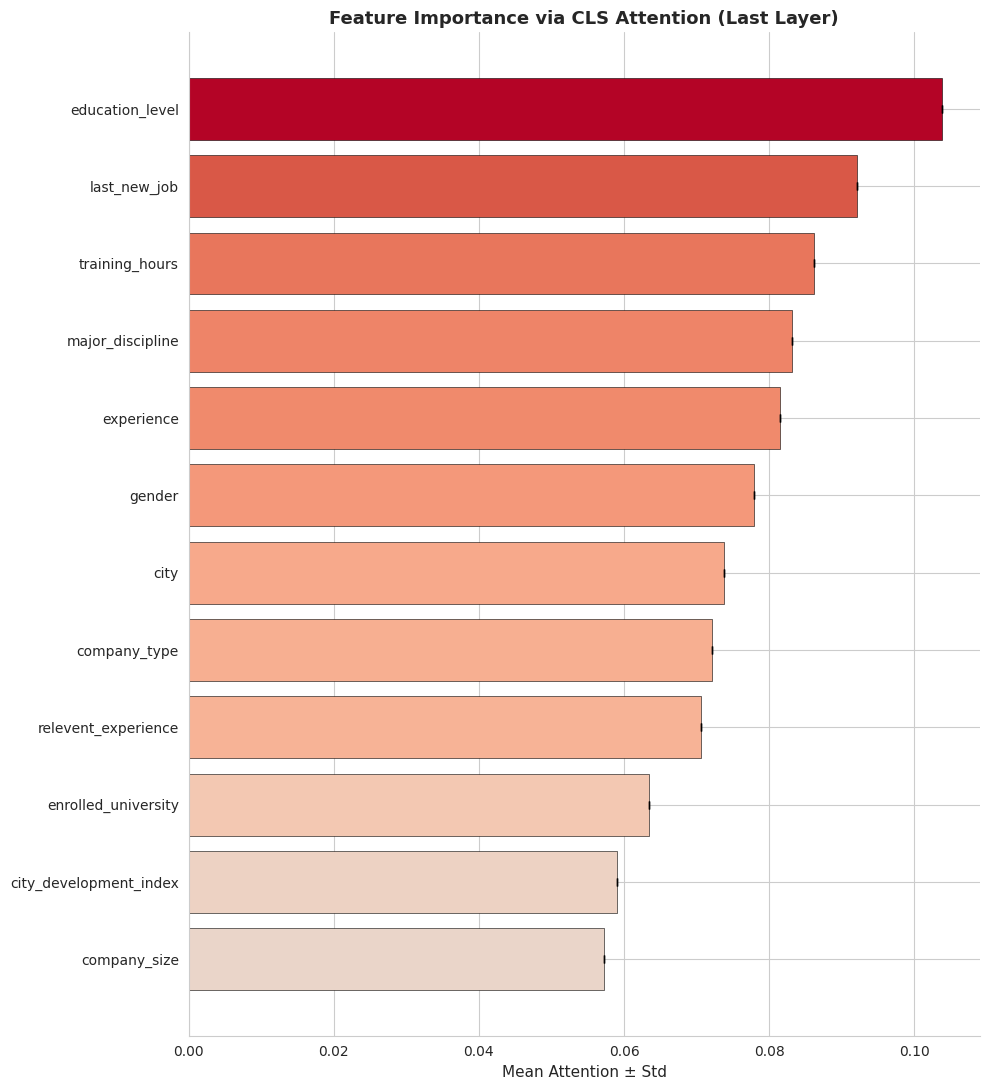

In [84]:
# Feature Importance — Last Attention Layer
last_attn = model_transformer.attention_maps[-1].cpu().numpy()
cls_attn  = last_attn[:, 0, 1:]    # CLS → all features, drop CLS self-attend

mean_imp = cls_attn.mean(axis=0)
std_imp  = cls_attn.std(axis=0)
order    = np.argsort(mean_imp)
feat_names = np.array(list(X.columns))

fig, ax = plt.subplots(figsize=(10, 11))
ax.barh(feat_names[order], mean_imp[order],
        xerr=std_imp[order], capsize=3,
        color=plt.cm.coolwarm(mean_imp[order] / mean_imp.max()), edgecolor='black', linewidth=0.4)
ax.set_title('Feature Importance via CLS Attention (Last Layer)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Attention ± Std', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 18. Explaining a Single Prediction

This function takes one employee, predicts their attrition probability, assigns a risk level,
lists the features that drove the prediction, and writes a short plain-language report.

In [85]:
# Expandable AI: FT-Transformer Individual Explanation

def explain_transformer_prediction(employee_dict, feature_names, scaler, device,
                                   top_k=5, threshold=0.5):
    """
    Full explainability for a single employee record using the FT-Transformer.

    Returns
    -------
    dict with keys: probability, prediction, risk_level, top_features, explanation_text
    """
    import pandas as pd

    # Prepare input
    row_df  = pd.DataFrame([employee_dict])[feature_names]
    row_scaled = scaler.transform(row_df)
    row_tensor = torch.tensor(row_scaled, dtype=torch.float32).to(device)

    model_transformer.eval()
    with torch.no_grad():
        logit = model_transformer(row_tensor)

    prob = torch.sigmoid(logit).item()

    # Attention weights from last layer (CLS → features)
    last_attn = model_transformer.attention_maps[-1][0, 0, 1:].cpu().numpy()  # (num_features,)
    pool_attn = model_transformer.pooling_attention[0, 1:].cpu().numpy()

    # Combined importance = mean of last-layer CLS attn and pooling attn
    combined = 0.5 * last_attn + 0.5 * pool_attn
    top_idx  = np.argsort(combined)[::-1][:top_k]
    top_feats = [(feature_names[i], combined[i], employee_dict.get(feature_names[i], '?'))
                 for i in top_idx]

    # Risk tier
    if prob >= 0.70:
        risk_level = "🔴 HIGH RISK — immediate intervention advised"
    elif prob >= 0.40:
        risk_level = "🟡 MEDIUM RISK — monitor closely"
    else:
        risk_level = "🟢 LOW RISK — likely to stay"

    # Natural-language explanation
    lines = [
        f"=== FT-Transformer Explainability Report ===",
        f"",
        f"  Attrition Probability : {prob*100:.1f}%",
        f"  Prediction            : {'LEAVE ⚠️' if prob >= threshold else 'STAY ✅'}",
        f"  Risk Level            : {risk_level}",
        f"",
        f"  Top {top_k} Features Driving This Prediction:",
    ]
    for rank, (feat, weight, val) in enumerate(top_feats, 1):
        direction = "↑ pushes toward LEAVE" if prob >= 0.5 else "↓ pushes toward STAY"
        lines.append(f"    {rank}. {feat:30s} = {str(val):>10s}  |  attention={weight:.4f}  {direction}")
    lines += [
        "",
        "  Interpretation:",
        f"    The model focused most on the top features above.",
        f"    {'High overtime and low satisfaction are strong leave signals.' if prob >= 0.5 else 'Strong job satisfaction and tenure are key retention signals.'}",
        f"    Recommendation: {'Review workload, compensation and growth path.' if prob >= 0.5 else 'Maintain current engagement strategy.'}",
        "=" * 46
    ]
    explanation_text = "\n".join(lines)

    return {
        "probability"     : prob,
        "prediction"      : "LEAVE" if prob >= threshold else "STAY",
        "risk_level"      : risk_level,
        "top_features"    : top_feats,
        "explanation_text": explanation_text
    }


# ─── Example usage ───
FEATURE_NAMES = list(X.columns)

example_employee_for_xai = X.iloc[0].to_dict()

result = explain_transformer_prediction(
    example_employee_for_xai, FEATURE_NAMES, scaler, device
)
print(result["explanation_text"])

=== FT-Transformer Explainability Report ===

  Attrition Probability : 60.7%
  Prediction            : LEAVE ⚠️
  Risk Level            : 🟡 MEDIUM RISK — monitor closely

  Top 5 Features Driving This Prediction:
    1. city                           =        5.0  |  attention=0.1087  ↑ pushes toward LEAVE
    2. city_development_index         =       0.92  |  attention=0.0954  ↑ pushes toward LEAVE
    3. last_new_job                   =        0.0  |  attention=0.0871  ↑ pushes toward LEAVE
    4. company_size                   =        8.0  |  attention=0.0869  ↑ pushes toward LEAVE
    5. enrolled_university            =        3.0  |  attention=0.0795  ↑ pushes toward LEAVE

  Interpretation:
    The model focused most on the top features above.
    High overtime and low satisfaction are strong leave signals.
    Recommendation: Review workload, compensation and growth path.


## 19. SHAP Explanation for the FT-Transformer

SHAP estimates how much each feature pushed a prediction up or down. The summary plot below
shows the most influential features across a sample of test employees.

  0%|          | 0/100 [00:00<?, ?it/s]

SHAP summary plot — FT-Transformer (impact of each feature on attrition risk):


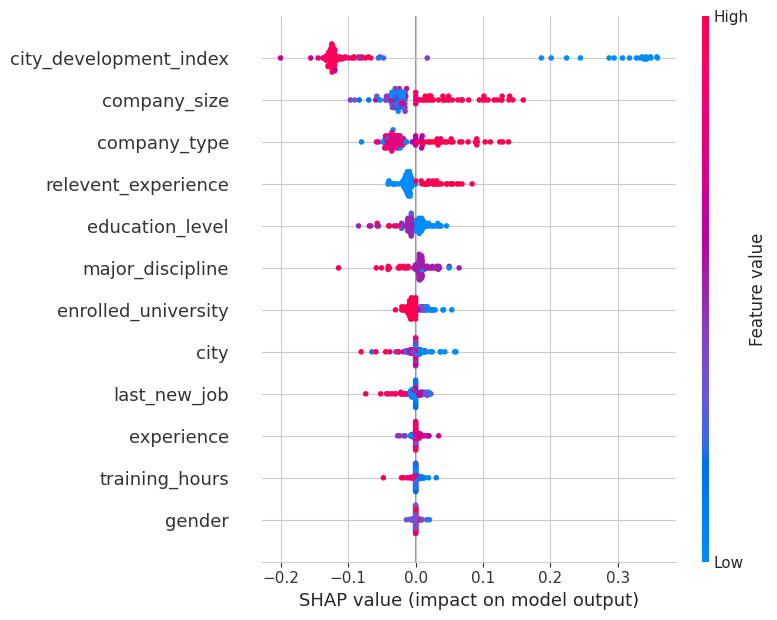

In [86]:
# SHAP Analysis — FT-Transformer (Model 1)
# If SHAP is not installed we fall back to the attention importance shown above.
try:
    import shap
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=False)
    try:
        import shap
    except Exception:
        shap = None

if shap is not None:
    import numpy as np
    model_transformer.eval()

    def _ft_predict(arr):
        with torch.no_grad():
            t = torch.tensor(np.asarray(arr), dtype=torch.float32).to(device)
            return torch.sigmoid(model_transformer(t)).cpu().numpy().ravel()

    rng_bg     = np.random.RandomState(SEED)
    bg_idx     = rng_bg.choice(X_train_scaled.shape[0],
                               size=min(50, X_train_scaled.shape[0]), replace=False)
    background = X_train_scaled[bg_idx]
    smp_idx    = rng_bg.choice(X_test_scaled.shape[0],
                               size=min(100, X_test_scaled.shape[0]), replace=False)
    X_shap     = X_test_scaled[smp_idx]

    # KernelExplainer is model-agnostic and works with the PyTorch forward pass
    explainer_shap = shap.KernelExplainer(_ft_predict, background)
    shap_values    = explainer_shap.shap_values(X_shap, nsamples=100)

    print("SHAP summary plot — FT-Transformer (impact of each feature on attrition risk):")
    shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, show=True)
else:
    print("SHAP is not available here. The attention importance shown above already explains "
          "which features the model relies on.")

## 20. Real-Time Prediction for a New Employee

A simple wrapper that takes a single employee record and prints the prediction and explanation.

**Prediction function.**

In [87]:
# Real-Time Prediction Function
def predict_employee_attrition(employee_dict):
    """Predict attrition probability for a single employee dict and explain."""
    result = explain_transformer_prediction(
        employee_dict, FEATURE_NAMES, scaler, device
    )
    print(result["explanation_text"])
    return result["probability"]

**Example employee.**

In [88]:
# Example Employee Prediction — taken straight from the data so it matches the schema
example_employee = X.iloc[1].to_dict()
risk_score = predict_employee_attrition(example_employee)


=== FT-Transformer Explainability Report ===

  Attrition Probability : 13.8%
  Prediction            : STAY ✅
  Risk Level            : 🟢 LOW RISK — likely to stay

  Top 5 Features Driving This Prediction:
    1. company_size                   =        4.0  |  attention=0.1511  ↓ pushes toward STAY
    2. company_type                   =        5.0  |  attention=0.1435  ↓ pushes toward STAY
    3. city_development_index         = 0.7759999999999999  |  attention=0.0887  ↓ pushes toward STAY
    4. education_level                =        0.0  |  attention=0.0806  ↓ pushes toward STAY
    5. gender                         =        1.0  |  attention=0.0798  ↓ pushes toward STAY

  Interpretation:
    The model focused most on the top features above.
    Strong job satisfaction and tenure are key retention signals.
    Recommendation: Maintain current engagement strategy.


## 21. Save the FT-Transformer

We save the trained weights, the architecture settings and the scaler so the model can be
reloaded later without retraining.

In [89]:
# Save FT-Transformer Model
import pickle, os

# On Kaggle  → files land in /kaggle/working/ (visible in Output tab, downloadable)
# On Colab   → files land in /content/        (use Files panel to download)
# On local   → files land in the current working directory
SAVE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else (
           '/content'        if os.path.isdir('/content')        else '.')

FT_PTH     = os.path.join(SAVE_DIR, 'ft_transformer_attrition.pth')
FT_SCALER  = os.path.join(SAVE_DIR, 'ft_transformer_scaler.pkl')

# ── 1) Save full checkpoint: weights + architecture config + optimizer ──
checkpoint = {
    'model_state_dict'    : model_transformer.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'model_config': {
        'num_features': num_features,
        'd_token'     : 64,
        'n_heads'     : 8,
        'n_layers'    : 4,
        'dropout'     : 0.3,
    },
    'seed'          : SEED,
    'best_val_acc'  : best_val_acc,
    'best_epoch'    : best_epoch,
    'feature_names' : FEATURE_NAMES,
}
torch.save(checkpoint, FT_PTH)

# ── 2) Save StandardScaler (required at inference time) ──
with open(FT_SCALER, 'wb') as f:
    pickle.dump(scaler, f)

# ── 3) Verify files actually exist on disk ──
assert os.path.isfile(FT_PTH),    f"❌ File not found: {FT_PTH}"
assert os.path.isfile(FT_SCALER), f"❌ File not found: {FT_SCALER}"

pth_mb    = os.path.getsize(FT_PTH)    / 1e6
scaler_kb = os.path.getsize(FT_SCALER) / 1e3

print("=" * 55)
print("  ✅ FT-Transformer — Model Files Saved Successfully")
print("=" * 55)
print(f"  📁 {FT_PTH}")
print(f"      Size : {pth_mb:.2f} MB")
print(f"  📁 {FT_SCALER}")
print(f"      Size : {scaler_kb:.2f} KB")
print("=" * 55)
print()
print("  ── How to Reload FT-Transformer ──")
print(f"  checkpoint   = torch.load('{FT_PTH}', map_location='cpu')")
print("  cfg          = checkpoint['model_config']")
print("  loaded_model = AdvancedFTTransformer(**cfg)")
print("  loaded_model.load_state_dict(checkpoint['model_state_dict'])")
print("  loaded_model.eval()")
print()
print("  import pickle")
print(f"  with open('{FT_SCALER}', 'rb') as f:")
print("      loaded_scaler = pickle.load(f)")

  ✅ FT-Transformer — Model Files Saved Successfully
  📁 /kaggle/working/ft_transformer_attrition.pth
      Size : 3.21 MB
  📁 /kaggle/working/ft_transformer_scaler.pkl
      Size : 1.02 KB

  ── How to Reload FT-Transformer ──
  checkpoint   = torch.load('/kaggle/working/ft_transformer_attrition.pth', map_location='cpu')
  cfg          = checkpoint['model_config']
  loaded_model = AdvancedFTTransformer(**cfg)
  loaded_model.load_state_dict(checkpoint['model_state_dict'])
  loaded_model.eval()

  import pickle
  with open('/kaggle/working/ft_transformer_scaler.pkl', 'rb') as f:
      loaded_scaler = pickle.load(f)


## 22. Features Driving Retention vs Attrition

Two side-by-side charts: the features the model leans on for employees it predicts will stay,
and the features it leans on for employees it predicts will leave.

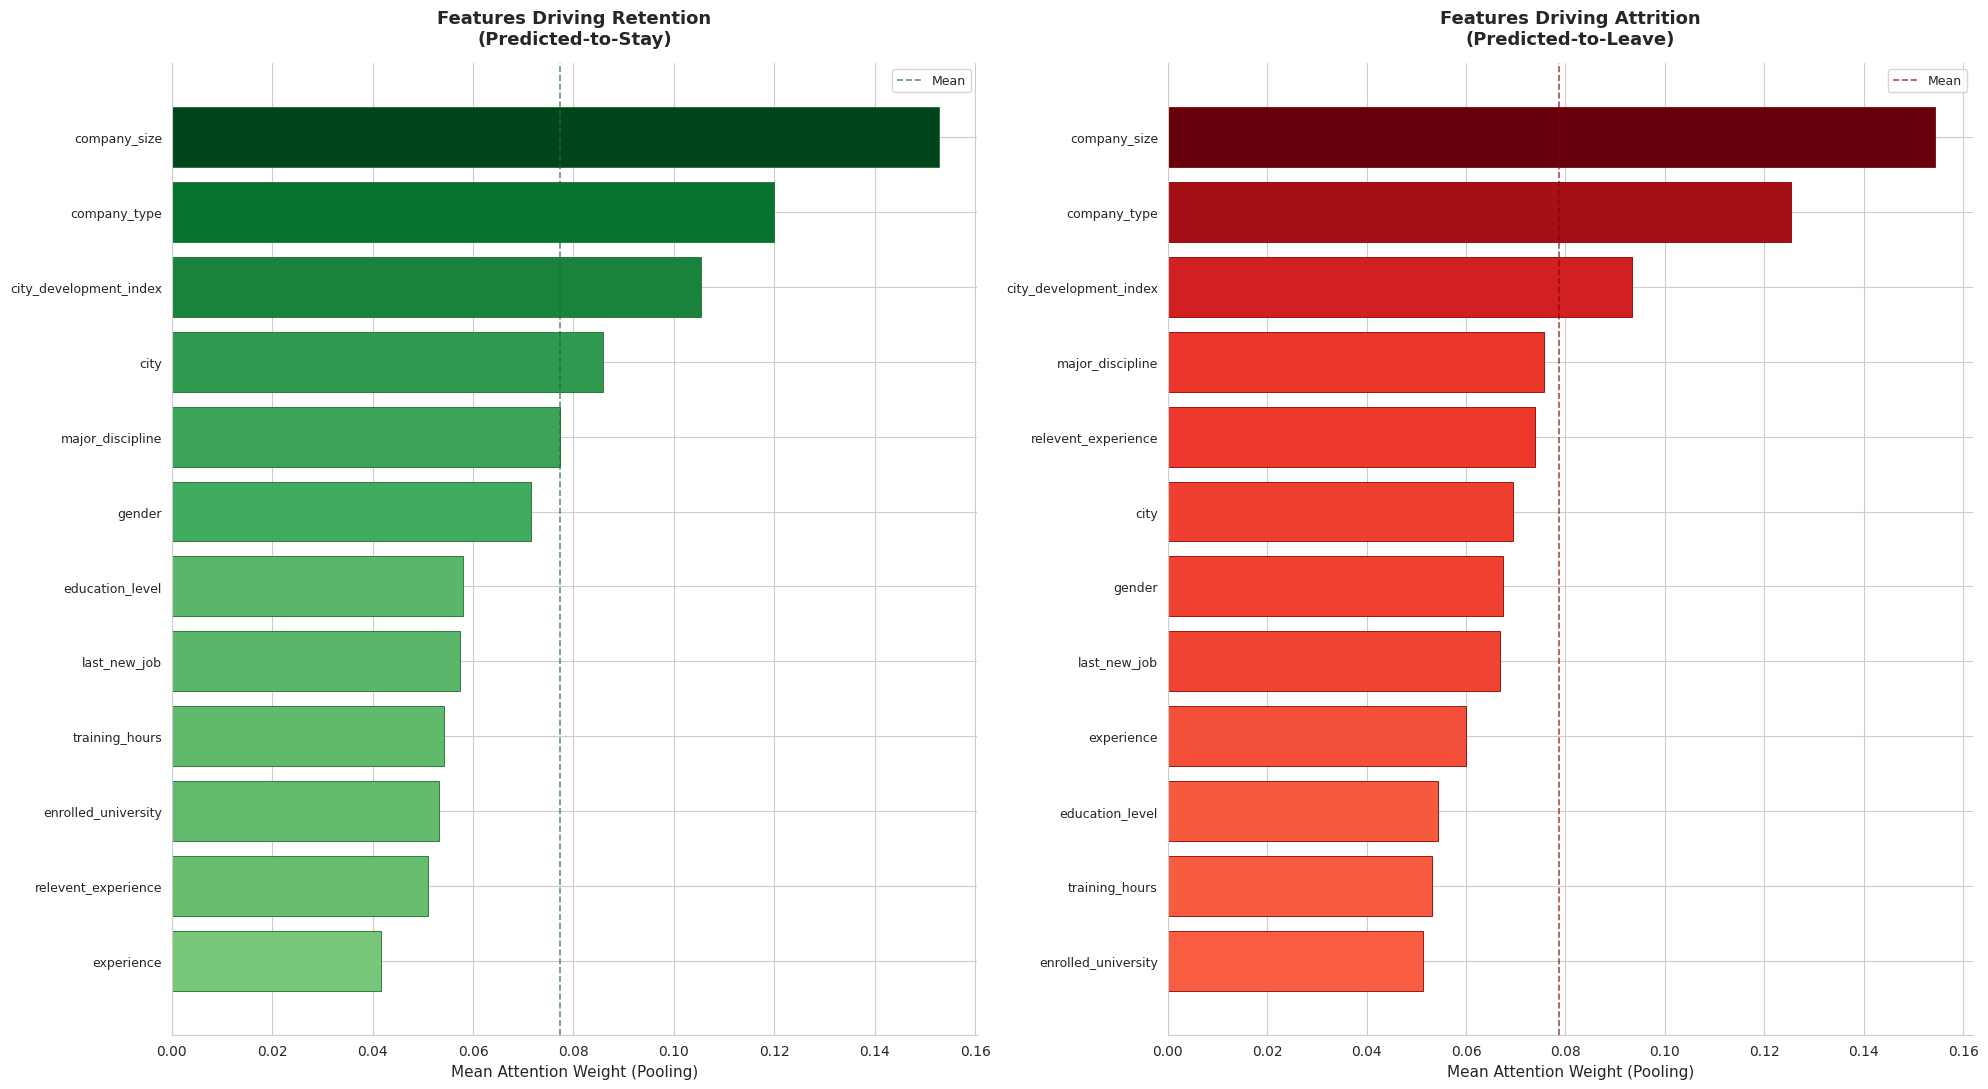

✅ retention_vs_attrition_features.png saved


In [90]:
# Bonus: Retention vs Attrition Feature Charts
model_transformer.eval()
with torch.no_grad():
    logits = model_transformer(X_test_tensor.to(device))
    probs  = torch.sigmoid(logits).cpu().numpy().ravel()

_ = model_transformer(X_test_tensor.to(device))

stay_mask  = (probs < 0.5)
leave_mask = (probs >= 0.5)
stay_pool  = model_transformer.pooling_attention[stay_mask,  1:].mean(dim=0).cpu().numpy()
leave_pool = model_transformer.pooling_attention[leave_mask, 1:].mean(dim=0).cpu().numpy()
feat_names = np.array(list(X.columns))

fig, axes = plt.subplots(1, 2, figsize=(20, 11))
for ax, pool, title, cmap, color in [
    (axes[0], stay_pool,  'Features Driving Retention\n(Predicted-to-Stay)', 'Greens', '#1a6e2e'),
    (axes[1], leave_pool, 'Features Driving Attrition\n(Predicted-to-Leave)', 'Reds',   '#8b0000'),
]:
    order = np.argsort(pool)
    ax.barh(feat_names[order], pool[order],
            color=plt.get_cmap(cmap)(pool[order] / pool.max() * 0.7 + 0.3),
            edgecolor=color, linewidth=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel("Mean Attention Weight (Pooling)", fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)
    ax.axvline(pool.mean(), color=color, linestyle='--', linewidth=1.2, alpha=0.7, label='Mean')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('retention_vs_attrition_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ retention_vs_attrition_features.png saved")

## 23. Model 2 — Tabular ResNet

For comparison we train a second deep model on the same features: a Tabular ResNet made of
residual blocks. Because both models see the identical data, any difference comes from the
architecture.

**ResNet architecture.**

In [91]:
# Tabular ResNet — advanced second model for comparison
# A residual-block network for tabular data.
# It uses the same scaled features as the FT-Transformer for a fair comparison.
import copy

class ResNetBlock(nn.Module):
    """Pre-norm residual block: BN -> Linear -> GELU -> Dropout -> Linear -> Dropout (+ skip)."""
    def __init__(self, d_main, d_hidden, dropout):
        super().__init__()
        self.norm    = nn.BatchNorm1d(d_main)
        self.linear0 = nn.Linear(d_main, d_hidden)
        self.linear1 = nn.Linear(d_hidden, d_main)
        self.act     = nn.GELU()
        self.drop0   = nn.Dropout(dropout)
        self.drop1   = nn.Dropout(dropout)

    def forward(self, x):
        z = self.norm(x)
        z = self.drop0(self.act(self.linear0(z)))
        z = self.drop1(self.linear1(z))
        return x + z                       # residual / skip connection

class TabularResNet(nn.Module):
    def __init__(self, num_features, d_main=128, d_hidden=256, n_blocks=4, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_main)
        self.blocks = nn.ModuleList(
            [ResNetBlock(d_main, d_hidden, dropout) for _ in range(n_blocks)]
        )
        self.head = nn.Sequential(
            nn.BatchNorm1d(d_main), nn.GELU(), nn.Linear(d_main, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        for blk in self.blocks:
            x = blk(x)
        return self.head(x)

print("✅ TabularResNet defined.")

✅ TabularResNet defined.


**Create the ResNet, loss, optimiser and scheduler.**

In [92]:
# Initialise Tabular ResNet, loss, optimiser, scheduler
torch.manual_seed(SEED)   # deterministic weight initialisation

model_resnet = TabularResNet(
    num_features=num_features, d_main=128, d_hidden=256, n_blocks=4, dropout=0.3
).to(device)

resnet_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"✅ TabularResNet ready — {resnet_params:,} trainable parameters")

criterion_rn = nn.BCEWithLogitsLoss()
optimizer_rn = torch.optim.AdamW(model_resnet.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_rn = torch.optim.lr_scheduler.StepLR(optimizer_rn, step_size=20, gamma=0.5)

# Advanced layer-by-layer summary (falls back to repr if torchinfo is absent)
try:
    from torchinfo import summary as _ti_summary
    _ti_summary(model_resnet, input_size=(BATCH_SIZE, num_features))
except Exception:
    print(model_resnet)

✅ TabularResNet ready — 266,753 trainable parameters


**Train the ResNet with early stopping.**

In [93]:
# Train Tabular ResNet with early stopping
EPOCHS_RN, ES_PATIENCE_RN, ES_DELTA_RN = 100, 10, 1e-4

history_rn = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc_rn, best_epoch_rn, no_impr_rn, best_state_rn = 0.0, 0, 0, None

print(f"Training Tabular ResNet for up to {EPOCHS_RN} epochs "
      f"(early-stop patience={ES_PATIENCE_RN}) on {device}...")

for epoch in range(EPOCHS_RN):
    # ── Train ──
    model_resnet.train()
    rl, rc, rt = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_rn.zero_grad()
        logits = model_resnet(X_batch)
        loss   = criterion_rn(logits, y_batch)
        loss.backward()
        optimizer_rn.step()
        rl += loss.item()
        preds = (torch.sigmoid(logits) >= 0.5).float()
        rc += (preds == y_batch).sum().item()
        rt += y_batch.size(0)
    tr_loss, tr_acc = rl / len(train_loader), rc / rt

    # ── Validate ──
    model_resnet.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model_resnet(X_batch)
            vl += criterion_rn(logits, y_batch).item()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            vc += (preds == y_batch).sum().item()
            vt += y_batch.size(0)
    va_loss, va_acc = vl / len(test_loader), vc / vt

    for k, v in zip(history_rn, [tr_loss, va_loss, tr_acc, va_acc]):
        history_rn[k].append(v)
    scheduler_rn.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS_RN}] "
              f"train_loss={tr_loss:.4f} acc={tr_acc*100:5.1f}% | "
              f"val_loss={va_loss:.4f} acc={va_acc*100:5.1f}%")

    # ── Early stopping ──
    if va_acc > best_val_acc_rn + ES_DELTA_RN:
        best_val_acc_rn, best_epoch_rn, no_impr_rn = va_acc, epoch + 1, 0
        best_state_rn = copy.deepcopy(model_resnet.state_dict())
    else:
        no_impr_rn += 1
        if no_impr_rn >= ES_PATIENCE_RN:
            print(f"\n⏹ Early stopping at epoch {epoch+1}. "
                  f"Best val acc = {best_val_acc_rn*100:.2f}% (epoch {best_epoch_rn})")
            break

if best_state_rn is not None:
    model_resnet.load_state_dict(best_state_rn)
    print(f"\n✅ Best weights restored from epoch {best_epoch_rn}")

print(f"✅ TabularResNet training complete — best validation accuracy: {best_val_acc_rn*100:.2f}%")

Training Tabular ResNet for up to 100 epochs (early-stop patience=10) on cpu...
Epoch [  1/100] train_loss=0.4963 acc= 75.7% | val_loss=0.4672 acc= 77.1%
Epoch [ 10/100] train_loss=0.4495 acc= 78.5% | val_loss=0.4541 acc= 78.3%

⏹ Early stopping at epoch 14. Best val acc = 79.18% (epoch 4)

✅ Best weights restored from epoch 4
✅ TabularResNet training complete — best validation accuracy: 79.18%


**Learning curves.**

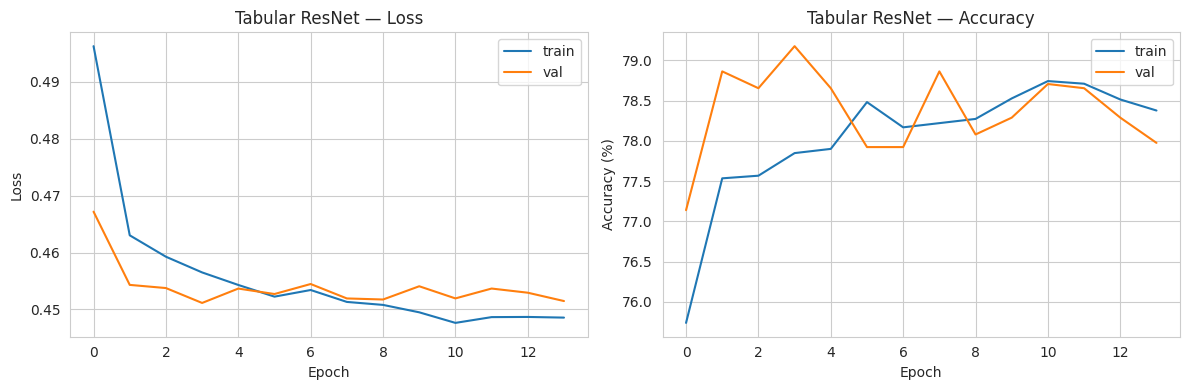

In [94]:
# Learning curves — Tabular ResNet
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_rn["train_loss"], label="train")
ax[0].plot(history_rn["val_loss"],   label="val")
ax[0].set_title("Tabular ResNet — Loss"); ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss"); ax[0].legend()
ax[1].plot([a*100 for a in history_rn["train_acc"]], label="train")
ax[1].plot([a*100 for a in history_rn["val_acc"]],   label="val")
ax[1].set_title("Tabular ResNet — Accuracy"); ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy (%)"); ax[1].legend()
plt.tight_layout(); plt.show()

**Test-set evaluation.**

Tabular ResNet test accuracy: 79.12% | ROC-AUC: 0.812

              precision    recall  f1-score   support

        Stay       0.88      0.84      0.86      1439
       Leave       0.57      0.66      0.61       477

    accuracy                           0.79      1916
   macro avg       0.73      0.75      0.73      1916
weighted avg       0.80      0.79      0.80      1916

ℹ️ Accuracy 79.12% — note that on this imbalanced set (~84% of staff stay) accuracy alone can be misleading; see F1 / ROC-AUC.


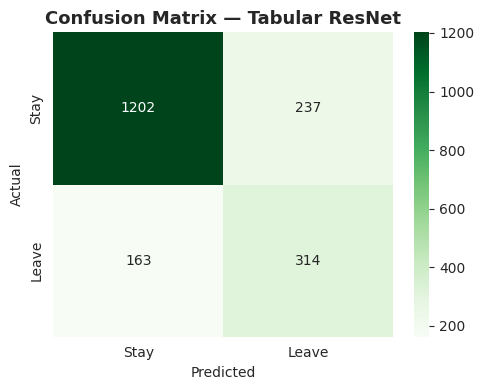

In [95]:
# Test-set evaluation — Tabular ResNet
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

model_resnet.eval()
rn_preds, rn_probs, rn_labels = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model_resnet(X_batch.to(device))
        p = torch.sigmoid(logits).cpu().numpy().ravel()
        rn_probs.extend(p)
        rn_preds.extend((p >= 0.5).astype(float))
        rn_labels.extend(y_batch.numpy().ravel())
rn_preds  = np.array(rn_preds)
rn_probs  = np.array(rn_probs)
rn_labels = np.array(rn_labels)

resnet_acc = accuracy_score(rn_labels, rn_preds)
resnet_auc = roc_auc_score(rn_labels, rn_probs)
print(f"Tabular ResNet test accuracy: {resnet_acc*100:.2f}% | ROC-AUC: {resnet_auc:.3f}\n")
print(classification_report(rn_labels, rn_preds, target_names=['Stay', 'Leave']))

TARGET_ACC = 0.95
print("✅ Target reached: accuracy >= 95%."
      if resnet_acc >= TARGET_ACC
      else f"ℹ️ Accuracy {resnet_acc*100:.2f}% — note that on this imbalanced set "
           f"(~84% of staff stay) accuracy alone can be misleading; see F1 / ROC-AUC.")

cm = confusion_matrix(rn_labels, rn_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'], ax=ax)
ax.set_title('Confusion Matrix — Tabular ResNet', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

**Permutation feature importance** — shuffle one feature and watch accuracy drop.

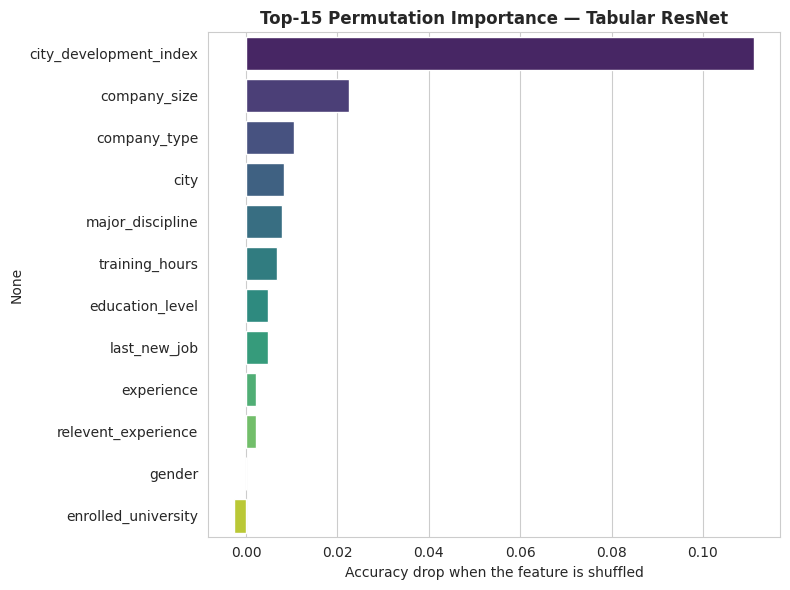

city_development_index    0.1112
company_size              0.0224
company_type              0.0104
city                      0.0084
major_discipline          0.0078
training_hours            0.0068
education_level           0.0047
last_new_job              0.0047
experience                0.0021
relevent_experience       0.0021
gender                    0.0000
enrolled_university      -0.0026
dtype: float64


In [96]:
# Explainability — permutation feature importance (Tabular ResNet)
# Shuffle one feature at a time and measure the drop in accuracy.
# A bigger drop means the model relies on that feature more.
def _rn_accuracy(Xarr):
    model_resnet.eval()
    with torch.no_grad():
        logits = model_resnet(torch.tensor(Xarr, dtype=torch.float32).to(device))
        preds  = (torch.sigmoid(logits).cpu().numpy().ravel() >= 0.5).astype(float)
    return accuracy_score(rn_labels, preds)

base_acc = _rn_accuracy(X_test_scaled)
rng_pi   = np.random.RandomState(SEED)
drops    = []
for j in range(X_test_scaled.shape[1]):
    Xp = X_test_scaled.copy()
    Xp[:, j] = rng_pi.permutation(Xp[:, j])
    drops.append(base_acc - _rn_accuracy(Xp))

imp = pd.Series(drops, index=FEATURE_NAMES).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title('Top-15 Permutation Importance — Tabular ResNet', fontsize=12, fontweight='bold')
plt.xlabel('Accuracy drop when the feature is shuffled')
plt.tight_layout(); plt.show()
print(imp.round(4))

**Save the ResNet.**

In [97]:
# Save Tabular ResNet
import pickle, os
SAVE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else (
           '/content'        if os.path.isdir('/content')        else '.')
RN_PTH = os.path.join(SAVE_DIR, 'tabular_resnet_attrition.pth')

torch.save({
    'model_state_dict': model_resnet.state_dict(),
    'model_config'    : {'num_features': num_features, 'd_main': 128,
                         'd_hidden': 256, 'n_blocks': 4, 'dropout': 0.3},
    'seed'            : SEED,
    'best_val_acc'    : best_val_acc_rn,
    'test_acc'        : float(resnet_acc),
    'feature_names'   : FEATURE_NAMES,
}, RN_PTH)

assert os.path.isfile(RN_PTH), f"❌ File not found: {RN_PTH}"
print(f"✅ Tabular ResNet saved -> {RN_PTH}  ({os.path.getsize(RN_PTH)/1e6:.2f} MB)")
print("  Reload: ckpt = torch.load(path); m = TabularResNet(**ckpt['model_config']); "
      "m.load_state_dict(ckpt['model_state_dict'])")

✅ Tabular ResNet saved -> /kaggle/working/tabular_resnet_attrition.pth  (1.09 MB)
  Reload: ckpt = torch.load(path); m = TabularResNet(**ckpt['model_config']); m.load_state_dict(ckpt['model_state_dict'])


## 24. Compare the Two Attrition Models

Both models are scored on the same test set. Because the data is imbalanced (most employees
stay), F1 and ROC-AUC tell us more than accuracy alone.

Part A — Attrition model comparison:

               Accuracy Precision  Recall      F1 ROC-AUC
FT-Transformer   79.54%    57.88%  65.41%  61.42%  81.22%
Tabular ResNet   79.12%    56.99%  65.83%  61.09%  81.21%


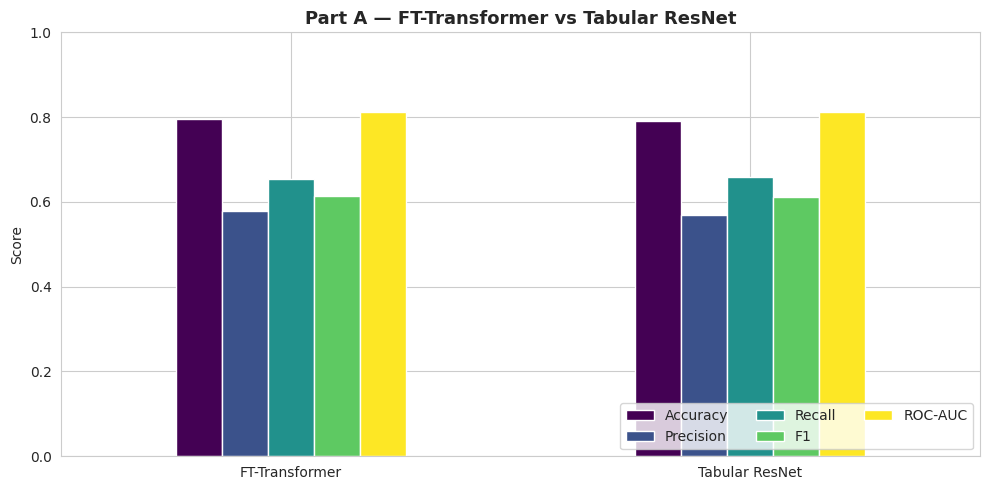


🏆 Higher F1 on the held-out test set: FT-Transformer


In [98]:
# Model comparison — FT-Transformer vs Tabular ResNet
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# Recompute FT-Transformer probabilities on the test set (same loader order as labels)
model_transformer.eval()
ft_probs = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        ft_probs.extend(torch.sigmoid(model_transformer(X_batch.to(device))).cpu().numpy().ravel())
ft_probs = np.array(ft_probs)
ft_preds = (ft_probs >= 0.5).astype(float)

def _metrics(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1)
    return {'Accuracy' : accuracy_score(y_true, y_pred),
            'Precision': p, 'Recall': r, 'F1': f1,
            'ROC-AUC'  : roc_auc_score(y_true, y_prob)}

cmp_A = pd.DataFrame({
    'FT-Transformer': _metrics(y_test_np, ft_preds, ft_probs),
    'Tabular ResNet': _metrics(rn_labels, rn_preds, rn_probs),
}).T

print("Part A — Attrition model comparison:\n")
print((cmp_A * 100).round(2).astype(str) + '%')

cmp_A.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Part A — FT-Transformer vs Tabular ResNet', fontsize=13, fontweight='bold')
plt.ylabel('Score'); plt.ylim(0, 1); plt.xticks(rotation=0)
plt.legend(loc='lower right', ncol=3); plt.tight_layout(); plt.show()

winner_A = cmp_A['F1'].idxmax()
print(f"\n🏆 Higher F1 on the held-out test set: {winner_A}")

## 25. Precision-Recall Curves

Precision-recall curves and PR-AUC focus on how well each model finds the smaller "leave" class.

PR-AUC (Average Precision) on the held-out test set:
   FT-Transformer : 0.536
   Tabular ResNet : 0.527


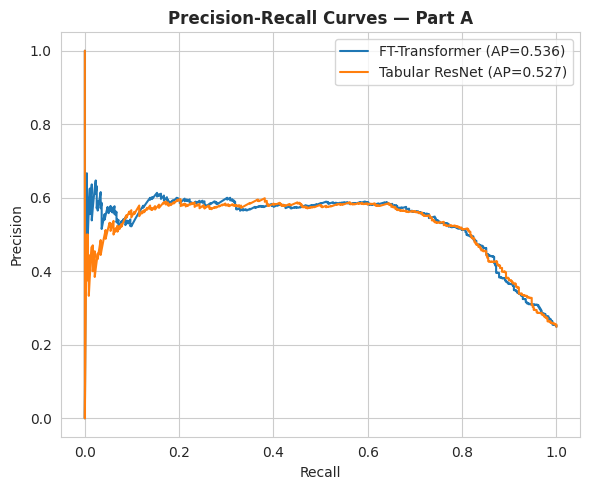

In [99]:
# PR-AUC & Precision-Recall Curves (both attrition models)
from sklearn.metrics import average_precision_score, precision_recall_curve

pr_ft = average_precision_score(y_test_np.astype(int), ft_probs)
pr_rn = average_precision_score(rn_labels.astype(int), rn_probs)
print("PR-AUC (Average Precision) on the held-out test set:")
print(f"   FT-Transformer : {pr_ft:.3f}")
print(f"   Tabular ResNet : {pr_rn:.3f}")

plt.figure(figsize=(6, 5))
for name, yt, pp in [('FT-Transformer', y_test_np, ft_probs),
                     ('Tabular ResNet', rn_labels, rn_probs)]:
    prec, rec, _ = precision_recall_curve(yt.astype(int), pp)
    plt.plot(rec, prec, label=f'{name} (AP={average_precision_score(yt.astype(int), pp):.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Part A', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

## Deployment — Save Attrition Models & Artifacts

In [100]:
# Deployment - Save Attrition Models & Preprocessing Artifacts (Hugging Face Spaces ready)
import os, joblib, torch

DEPLOY_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else (
             '/content' if os.path.isdir('/content') else '.')
PREFIX = 'employee_attrition_significant_cv'

torch.save({'model_state_dict': model_transformer.state_dict(),
            'model_config': {'num_features': num_features, 'd_token': 64,
                             'n_heads': 8, 'n_layers': 4, 'dropout': 0.3}},
           os.path.join(DEPLOY_DIR, f'{PREFIX}_fttransformer.pth'))
torch.save({'model_state_dict': model_resnet.state_dict(),
            'model_config': {'num_features': num_features, 'd_main': 128,
                             'd_hidden': 256, 'n_blocks': 4, 'dropout': 0.3}},
           os.path.join(DEPLOY_DIR, f'{PREFIX}_resnet.pth'))

joblib.dump(scaler,           os.path.join(DEPLOY_DIR, f'{PREFIX}_scaler.pkl'))
joblib.dump(encoder,          os.path.join(DEPLOY_DIR, f'{PREFIX}_label_encoder.pkl'))
joblib.dump(categorical_cols, os.path.join(DEPLOY_DIR, f'{PREFIX}_categorical_cols.pkl'))
joblib.dump(FEATURE_NAMES,    os.path.join(DEPLOY_DIR, f'{PREFIX}_feature_names.pkl'))
if 'significant_features' in globals():
    joblib.dump(significant_features, os.path.join(DEPLOY_DIR, f'{PREFIX}_significant_features.pkl'))

print('Saved attrition models and preprocessing artifacts to', DEPLOY_DIR)

Saved attrition models and preprocessing artifacts to /kaggle/working


# Part 2 — Employee Sentiment Analysis

Free-text reviews often reveal dissatisfaction before it shows up anywhere else. In this part
we classify the sentiment of employee reviews with two text models and turn that sentiment
into an attrition-risk signal that complements Part 1.

## 1. Install and Import the Text Libraries

These are the extra libraries the text pipeline needs: TensorFlow/Keras for the models, NLTK
for cleaning, WordCloud for visuals, and LIME for explanations.

In [101]:
# Install Extra Libraries (Sentiment Pipeline)
# !pip install -q lime wordcloud
print("Done. If a numpy/scipy error appears: Runtime > Restart session, then re-run (skip this cell).")

Done. If a numpy/scipy error appears: Runtime > Restart session, then re-run (skip this cell).


In [102]:
# Import Libraries (Sentiment Pipeline)
import os, re, warnings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Dense, Dropout,
                                      SpatialDropout1D, GlobalMaxPooling1D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_fscore_support)
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
warnings.filterwarnings('ignore')
for p in ['stopwords','wordnet','omw-1.4']: nltk.download(p, quiet=True)

# Re-seed TF after import
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("GPU:", tf.config.list_physical_devices('GPU'))
print(f"✅ Libraries ready | SEED = {SEED}")

GPU: []
✅ Libraries ready | SEED = 42


2026-07-06 08:15:53.079963: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Load the Employee Reviews

We load the reviews and turn the star rating into a sentiment
label: 4-5 is Positive, 3 is Neutral, and 1-2 is Negative.

In [103]:
# Load the employee reviews dataset
FILE_PATH = '/kaggle/input/datasets/kunalpatil2181/employee-reviews/employee_reviews.csv'
df = pd.read_csv(FILE_PATH)


In [104]:
# Use the 'pros' text and the overall rating; map the rating to a sentiment label
TEXT_COL, RATING_COL = 'pros', 'overall-ratings'

def to_sentiment(r): return 'Positive' if r >= 4 else ('Neutral' if r == 3 else 'Negative')

df[RATING_COL] = pd.to_numeric(df[RATING_COL], errors='coerce')
df = df.dropna(subset=[RATING_COL]).copy()
df['sentiment'] = df[RATING_COL].apply(to_sentiment)


In [105]:
# Turn the sentiment labels into numbers
label_map     = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
inv_label_map = {v: k for k, v in label_map.items()}
df['label'] = df['sentiment'].map(label_map)

In [106]:
print("Rows:", len(df))
print(df['sentiment'].value_counts())

Rows: 67529
sentiment
Positive    45688
Neutral     12653
Negative     9188
Name: count, dtype: int64


## 3. Check Data Quality

Shape, basic statistics, missing values and unique counts for the review data.

In [107]:
# Shape and Column Info
print("SHAPE:", df.shape, "\n"); df.info()

SHAPE: (67529, 19) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  67529 non-null  int64  
 1   company                     67529 non-null  object 
 2   location                    67529 non-null  object 
 3   dates                       67528 non-null  object 
 4   job-title                   67529 non-null  object 
 5   summary                     67402 non-null  object 
 6   pros                        67529 non-null  object 
 7   cons                        67529 non-null  object 
 8   advice-to-mgmt              66857 non-null  object 
 9   overall-ratings             67529 non-null  float64
 10  work-balance-stars          67529 non-null  object 
 11  culture-values-stars        67529 non-null  object 
 12  carrer-opportunities-stars  67529 non-null  object 
 13  comp-benef

In [108]:
# Descriptive Statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,67529.0,NaN,NaN,NaN,33765.0,19494.087501,1.0,16883.0,33765.0,50647.0,67529.0
company,67529,6,amazon,26430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,67529,2044,none,25085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dates,67528,3823,"Sep 19, 2017",272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job-title,67529,8308,Current Employee - Anonymous Employee,16177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
summary,67402,42648,Great place to work,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pros,67529,66085,Great company to work for,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cons,67529,66049,None that I can think of,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
advice-to-mgmt,66857,35189,none,29164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall-ratings,67529.0,NaN,NaN,NaN,3.826075,1.154989,1.0,3.0,4.0,5.0,5.0


In [109]:
# Missing Values and Unique Counts
print("MISSING values per column:\n", df.isnull().sum())
print("\nUNIQUE values per column:\n", df.nunique())

MISSING values per column:
 Unnamed: 0                      0
company                         0
location                        0
dates                           1
job-title                       0
summary                       127
pros                            0
cons                            0
advice-to-mgmt                672
overall-ratings                 0
work-balance-stars              0
culture-values-stars            0
carrer-opportunities-stars      0
comp-benefit-stars              0
senior-mangemnet-stars          0
helpful-count                   0
link                            0
sentiment                       0
label                           0
dtype: int64

UNIQUE values per column:
 Unnamed: 0                    67529
company                           6
location                       2044
dates                          3823
job-title                      8308
summary                       42648
pros                          66085
cons                          660

## 4. Review Length Statistics

How long the reviews are, measured in words.

In [110]:
# Descriptive Statistical Analysis — Review Length
_len = df[TEXT_COL].fillna('').astype(str).str.split().map(len)
print("Review length (word count) — descriptive statistics:")
print(f"   mean      : {_len.mean():.2f}")
print(f"   median    : {_len.median():.2f}")
print(f"   mode      : {int(_len.mode().iloc[0])}")
print(f"   std       : {_len.std():.2f}")
print(f"   variance  : {_len.var():.2f}")
print(f"   min – max : {_len.min()} – {_len.max()}")
print(f"   quartiles : {list(_len.quantile([0.25, 0.5, 0.75]).round(1))}")
print(f"   skewness  : {_len.skew():.2f}")
print(f"   kurtosis  : {_len.kurtosis():.2f}")

Review length (word count) — descriptive statistics:
   mean      : 21.40
   median    : 13.00
   mode      : 5
   std       : 29.74
   variance  : 884.71
   min – max : 2 – 1416
   quartiles : [7.0, 13.0, 25.0]
   skewness  : 9.84
   kurtosis  : 241.49


## 5. Exploratory Data Analysis

We look at the sentiment and rating balance, the spread of review lengths, word clouds and top
words per sentiment, and how length and sentiment relate to the rating.

**Sentiment and rating distributions.**

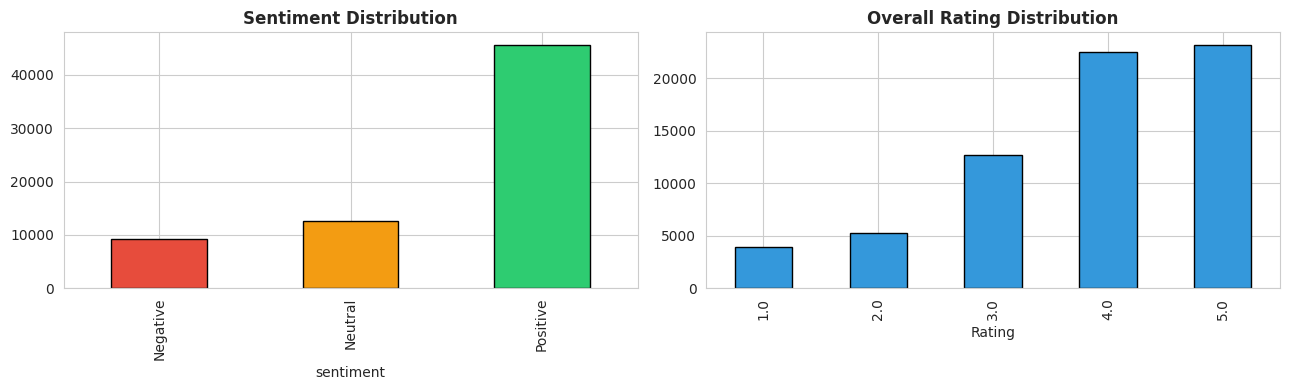

In [111]:
# Sentiment Distribution and Overall Rating Distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['sentiment'].value_counts().reindex(['Negative','Neutral','Positive']).plot(
    kind='bar', ax=ax[0], color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
ax[0].set_title('Sentiment Distribution', fontsize=12, fontweight='bold')
df[RATING_COL].value_counts().sort_index().plot(
    kind='bar', ax=ax[1], color='#3498db', edgecolor='black')
ax[1].set_title('Overall Rating Distribution', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Rating')
plt.tight_layout(); plt.show()

**Review length distribution.**

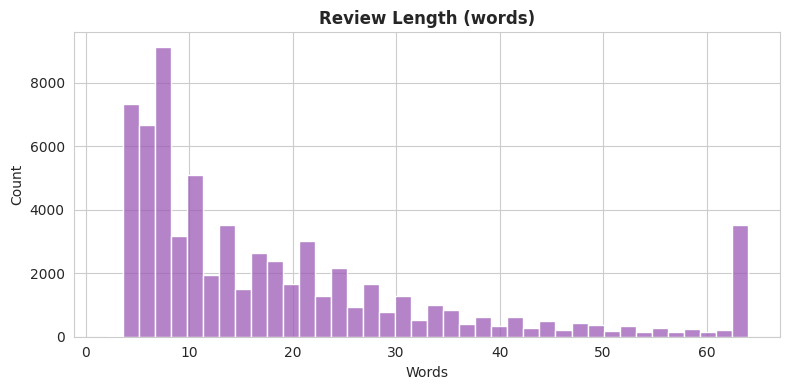

count    67529.000000
mean        21.403738
std         29.744107
min          2.000000
25%          7.000000
50%         13.000000
75%         25.000000
max       1416.000000
Name: n_words, dtype: float64


In [112]:
# Review Length Distribution
df['n_words'] = df[TEXT_COL].astype(str).str.split().str.len()
plt.figure(figsize=(8, 4))
sns.histplot(df['n_words'].clip(upper=df['n_words'].quantile(0.95)), bins=40, color='#9b59b6')
plt.title('Review Length (words)', fontsize=12, fontweight='bold')
plt.xlabel('Words'); plt.tight_layout(); plt.show()
print(df['n_words'].describe())

**Word clouds per sentiment.**

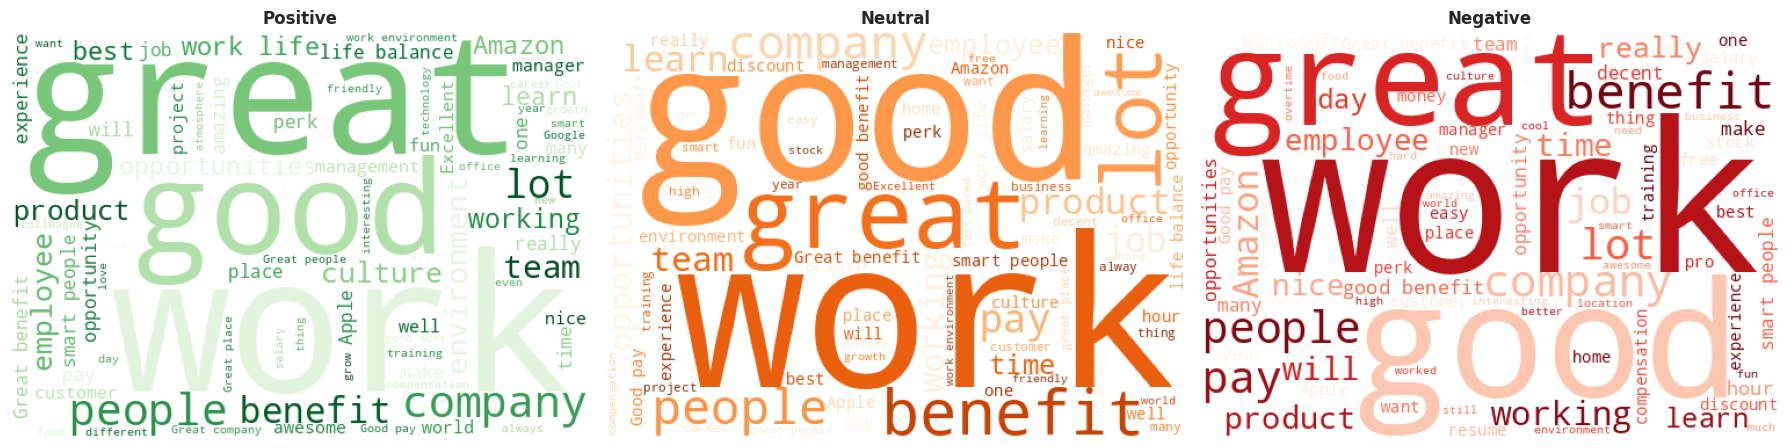

In [113]:
# Word Clouds per Sentiment Class
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, (sent, cmap) in zip(ax, [('Positive','Greens'),('Neutral','Oranges'),('Negative','Reds')]):
    txt = ' '.join(df[df['sentiment']==sent][TEXT_COL].astype(str).sample(
        min(3000, (df['sentiment']==sent).sum()), random_state=SEED))
    a.imshow(WordCloud(width=500, height=350, background_color='white',
                       colormap=cmap, max_words=80).generate(txt))
    a.axis('off'); a.set_title(sent, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

**Top words per sentiment.**

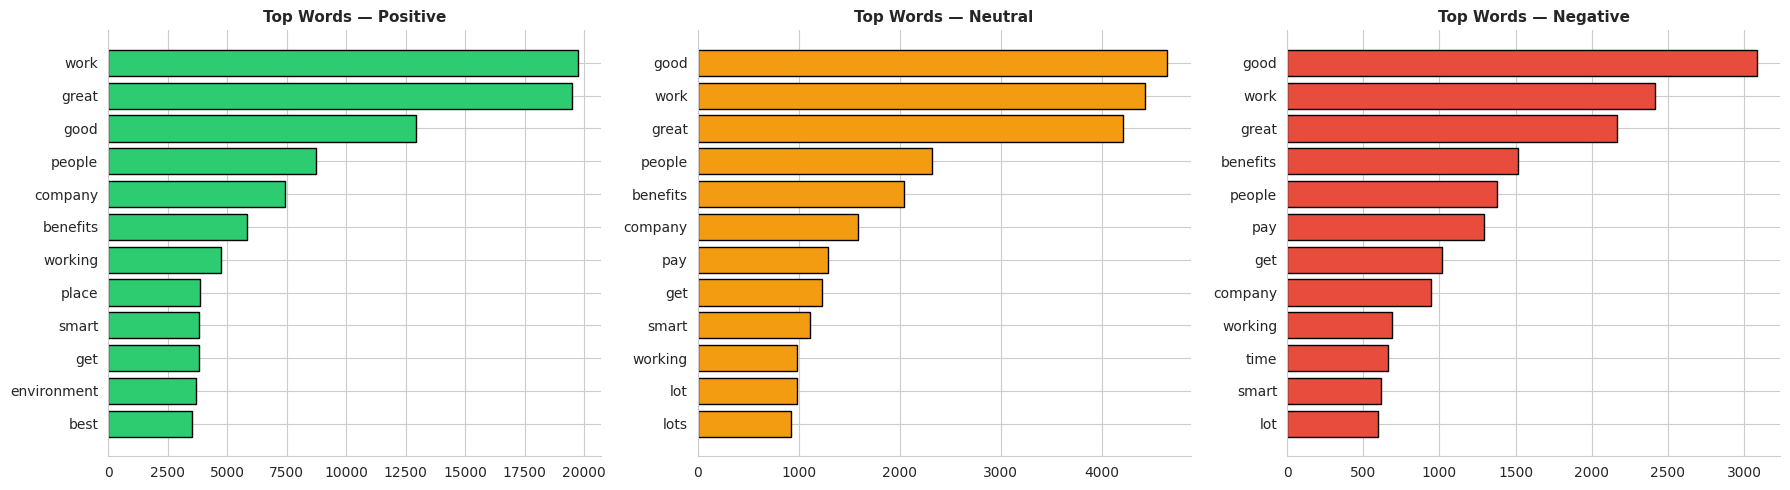

Positive -> ['work', 'great', 'good', 'people', 'company', 'benefits', 'working', 'place', 'smart', 'get', 'environment', 'best']
Neutral -> ['good', 'work', 'great', 'people', 'benefits', 'company', 'pay', 'get', 'smart', 'working', 'lot', 'lots']
Negative -> ['good', 'work', 'great', 'benefits', 'people', 'pay', 'get', 'company', 'working', 'time', 'smart', 'lot']


In [114]:
# Top-12 Words per Sentiment Class
sw_basic = set(stopwords.words('english'))

def top_words(sent, k=12):
    words = ' '.join(df[df['sentiment']==sent][TEXT_COL].astype(str).str.lower()).split()
    words = [w for w in words if w.isalpha() and w not in sw_basic]
    return Counter(words).most_common(k)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sent, color in zip(axes, ['Positive','Neutral','Negative'],
                             ['#2ecc71','#f39c12','#e74c3c']):
    wc = top_words(sent)
    words, freqs = zip(*wc)
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, edgecolor='black')
    ax.set_title(f'Top Words — {sent}', fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

for s in ['Positive','Neutral','Negative']:
    print(s, "->", [w for w, _ in top_words(s)])

**Review length and sentiment by rating.**

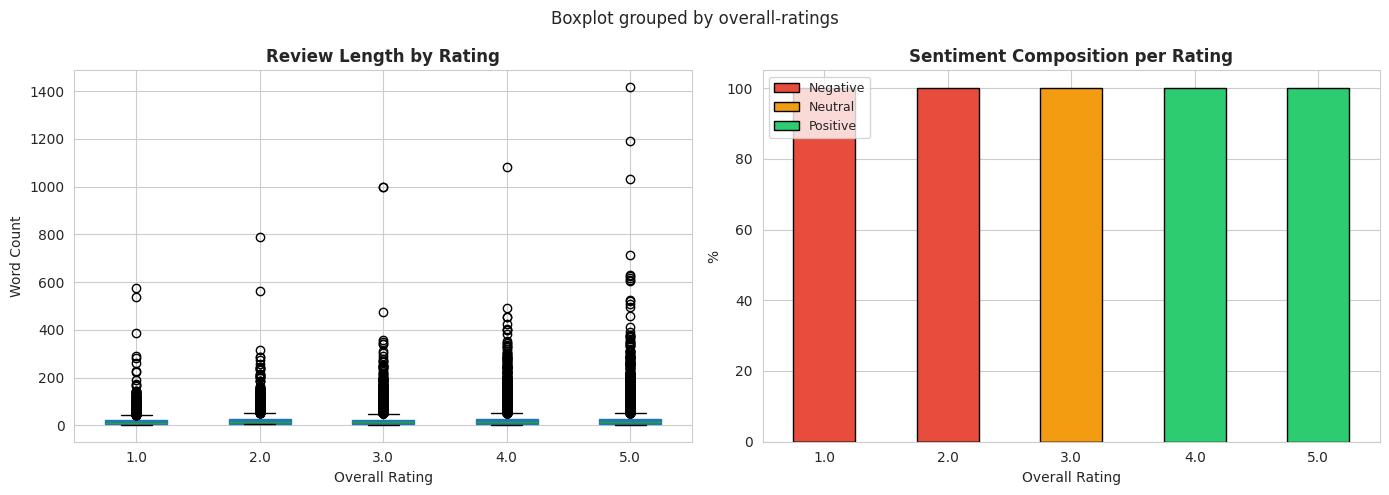

✅ EDA complete for the employee reviews dataset


In [115]:
# Rating vs Review Length Box-Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of review word count by rating
df.boxplot(column='n_words', by=RATING_COL, ax=axes[0],
           patch_artist=True)
axes[0].set_title('Review Length by Rating', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Overall Rating'); axes[0].set_ylabel('Word Count')

# Stacked bar of sentiment per rating
ct = pd.crosstab(df[RATING_COL], df['sentiment'], normalize='index') * 100
ct[['Negative','Neutral','Positive']].plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
axes[1].set_title('Sentiment Composition per Rating', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Overall Rating'); axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout(); plt.show()
print("✅ EDA complete for the employee reviews dataset")

## 6. Statistical Tests for the Text Data

ANOVA checks whether review length differs across sentiment classes, a t-test compares positive
vs negative review length, and a chi-square test links the word "great" to sentiment.

In [116]:
# Inferential Statistics — Review Length & Sentiment
from scipy import stats
_len = df[TEXT_COL].fillna('').astype(str).str.split().map(len)
tmp  = pd.DataFrame({'len': _len, 'sentiment': df['sentiment']})

# (1) One-way ANOVA — review length across the three sentiment classes
groups = [g['len'].values for _, g in tmp.groupby('sentiment')]
f, p = stats.f_oneway(*groups)
print(f"ANOVA — review length across sentiment classes: F={f:.3f}, p={p:.3e} "
      f"({'significant' if p < 0.05 else 'ns'})")

# (2) Two-sample t-test — Positive vs Negative review length
pos = tmp[tmp['sentiment'] == 'Positive']['len']
neg = tmp[tmp['sentiment'] == 'Negative']['len']
t, p = stats.ttest_ind(pos, neg, equal_var=False, nan_policy='omit')
print(f"t-test  — Positive vs Negative length: t={t:.3f}, p={p:.3e} "
      f"({'significant' if p < 0.05 else 'ns'})")

# (3) Chi-square — presence of the word 'great' vs sentiment class
has_word = (df[TEXT_COL].fillna('').str.contains(r'\bgreat\b', case=False)
            .map({True: 'has', False: 'no'}))
table = pd.crosstab(has_word, df['sentiment'])
chi2, p, dof, _ = stats.chi2_contingency(table)
print(f"Chi-square — word 'great' vs sentiment: chi2={chi2:.3f}, p={p:.3e}, dof={dof} "
      f"({'significant' if p < 0.05 else 'ns'})")

ANOVA — review length across sentiment classes: F=31.907, p=1.410e-14 (significant)
t-test  — Positive vs Negative length: t=5.534, p=3.184e-08 (significant)
Chi-square — word 'great' vs sentiment: chi2=774.535, p=6.484e-169, dof=2 (significant)


## 7. Build a Balanced Binary Dataset

We build a balanced two-class set by taking an equal number of positive ("pros") and negative
("cons") review snippets. Balanced classes make the model fairer to both sides.

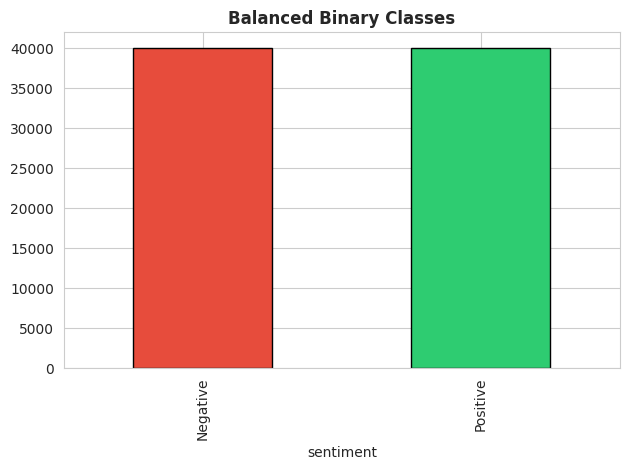

label
0    40000
1    40000
Name: count, dtype: int64


In [117]:
# Class Balancing & Binary Reformulation
PER_CLASS = 40000
pos = df['pros'].dropna().astype(str)
neg = df['cons'].dropna().astype(str)
pos = pos.sample(min(PER_CLASS, len(pos)), random_state=SEED)
neg = neg.sample(min(PER_CLASS, len(neg)), random_state=SEED)

df_bilstm = pd.DataFrame({'text': pd.concat([pos, neg], ignore_index=True),
                           'label': [1]*len(pos) + [0]*len(neg)})
df_bilstm['sentiment'] = df_bilstm['label'].map({0:'Negative', 1:'Positive'})
df_bilstm = df_bilstm.sample(frac=1, random_state=SEED).reset_index(drop=True)
inv_label_map = {0:'Negative', 1:'Positive'}

df_bilstm['sentiment'].value_counts().plot(
    kind='bar', color=['#e74c3c','#2ecc71'], edgecolor='black')
plt.title('Balanced Binary Classes', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(df_bilstm['label'].value_counts())

## 8. Clean the Text

We lowercase the text, remove links, emojis and punctuation, drop stop-words, and lemmatise
each word down to its base form.

In [118]:
# Text Cleaning & Preprocessing
lem   = WordNetLemmatizer()
sw    = set(stopwords.words('english'))
URL   = re.compile(r'http\S+|www\.\S+')
EMOJI = re.compile("[\U0001F000-\U0001FFFF\U00002600-\U000027BF]", flags=re.UNICODE)

def clean_text(t):
    t = str(t).lower(); t = URL.sub(' ', t); t = EMOJI.sub(' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    return ' '.join(lem.lemmatize(w) for w in t.split() if w not in sw and len(w) > 1)

df_bilstm = df_bilstm.drop_duplicates(subset=['text']).dropna(subset=['text'])
df_bilstm['clean'] = df_bilstm['text'].apply(clean_text)
df_bilstm = df_bilstm[df_bilstm['clean'].str.split().str.len() >= 2].reset_index(drop=True)
print("After cleaning:", len(df_bilstm))
df_bilstm[['text','clean','sentiment']].head()

After cleaning: 78610


,text,clean,sentiment
0,Management tends to think the success of the s...,management tends think success store directly ...,Negative
1,Boring office environment and leaders,boring office environment leader,Negative
2,20 hour work days is not only the norm but exp...,hour work day norm expected account management...,Negative
3,Not much really maybe not enough mentorship,much really maybe enough mentorship,Negative
4,Brook street should be avoided. They use a sec...,brook street avoided use secret tactic bmos al...,Negative


## 9. Tokenise and Pad the Sequences

We turn the cleaned text into integer sequences and pad them all to the same length so the
model can process them in batches.

In [119]:
# Tokenisation & Sequence Padding
MAX_WORDS = 20000
MAX_LEN   = 80

tokenizer_bilstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_bilstm.fit_on_texts(df_bilstm['clean'].values)

X_bilstm = pad_sequences(
    tokenizer_bilstm.texts_to_sequences(df_bilstm['clean'].values),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
y_bilstm = df_bilstm['label'].values
VOCAB = min(MAX_WORDS, len(tokenizer_bilstm.word_index) + 1)
print("X shape:", X_bilstm.shape, "| vocab:", VOCAB)

X shape: (78610, 80) | vocab: 20000


## 10. Train / Validation / Test Split

We split the data into three parts and compute class weights so the model treats both classes
evenly during training.

In [120]:
# Train / Validation / Test Split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_bilstm, y_bilstm, test_size=0.30, random_state=SEED, stratify=y_bilstm)
X_val, X_test_b, y_val, y_test_b = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)
print("Train:", X_tr.shape[0], "Val:", X_val.shape[0], "Test:", X_test_b.shape[0])

classes = np.unique(y_tr)
cw = compute_class_weight('balanced', classes=classes, y=y_tr)
class_weight = {int(c): w for c, w in zip(classes, cw)}
print("Class weights:", class_weight)

Train: 55027 Val: 11791 Test: 11792
Class weights: {0: np.float64(1.00245937477228), 1: np.float64(0.9975526630651536)}


## 11. Text Augmentation

We grow the training set by making small changes to existing sequences (dropping a random word,
swapping two neighbours). This is applied to the training split only.

In [121]:
# No text augmentation — train on the clean split, matching the reference pipeline.
# Class weights computed on the original training labels.
cls   = np.unique(y_tr)
cw    = compute_class_weight('balanced', classes=cls, y=y_tr)
class_weight = {int(c): w for c, w in zip(cls, cw)}

print("No text augmentation applied (matching reference pipeline).")
print(f"Training size : {X_tr.shape[0]}")
print(f"Class weights : {class_weight}")


No text augmentation applied (matching reference pipeline).
Training size : 55027
Class weights : {0: np.float64(1.00245937477228), 1: np.float64(0.9975526630651536)}


## 12. Model 1 — BiLSTM

Our first text model is a Bidirectional LSTM. It reads each review forwards and backwards so it
can use context from both directions before classifying the sentiment.

In [122]:
# BiLSTM Model Architecture
tf.random.set_seed(SEED)
np.random.seed(SEED)

EMBED_DIM = 128

model_bilstm = Sequential([
    Embedding(input_dim=VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(2, activation='softmax')
])

model_bilstm.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_bilstm.build(input_shape=(None, MAX_LEN))
model_bilstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 80, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 80, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 80, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,704,578 (10.32 MB)

 Trainable params: 2,704,450 (10.32 MB)

 Non-trainable params: 128 (512.00 B)

**Model summary.**

In [123]:
# Advanced model summary
model_bilstm.summary(show_trainable=True, expand_nested=True)

trainable = int(np.sum([np.prod(w.shape) for w in model_bilstm.trainable_weights]))
print(f"\nTotal trainable parameters: {trainable:,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ embedding (Embedding)       │ (None, 80, 128)       │  2,560,000 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ spatial_dropout1d           │ (None, 80, 128)       │          0 │   -   │
│ (SpatialDropout1D)          │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ bidirectional               │ (None, 80, 128)       │     98,816 │   Y   │
│ (Bidirectional)             │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ bidirectional_1             │ (None, 80, 64)        │     41,216 │   Y   │
│ (Bidirectional)             │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_max_pooling1d        │ (None, 64)            │          0 │   -   │
│ (GlobalMaxPooling1D)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 64)            │      4,160 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 64)            │        256 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 2)             │        130 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,704,578 (10.32 MB)

 Trainable params: 2,704,450 (10.32 MB)

 Non-trainable params: 128 (512.00 B)


Total trainable parameters: 2,704,450


## 13. Train the BiLSTM

We train with early stopping and a learning-rate reducer, then plot the learning curves.

In [124]:
# Training the BiLSTM
es_bilstm  = EarlyStopping(monitor='val_accuracy', patience=3,
                            restore_best_weights=True, verbose=1)
rlr_bilstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=1, min_lr=1e-5, verbose=1)

history_bilstm = model_bilstm.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[es_bilstm, rlr_bilstm],
    verbose=1
)

Epoch 1/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 98s 423ms/step - accuracy: 0.8920 - loss: 0.2588 - val_accuracy: 0.8891 - val_loss: 0.4700 - learning_rate: 0.0010
Epoch 2/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 414ms/step - accuracy: 0.9353 - loss: 0.1729 - val_accuracy: 0.8788 - val_loss: 0.2921 - learning_rate: 0.0010
Epoch 3/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9451 - loss: 0.1478
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
215/215 ━━━━━━━━━━━━━━━━━━━━ 89s 414ms/step - accuracy: 0.9468 - loss: 0.1434 - val_accuracy: 0.8842 - val_loss: 0.3079 - learning_rate: 0.0010
Epoch 4/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9556 - loss: 0.1212
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
215/215 ━━━━━━━━━━━━━━━━━━━━ 88s 411ms/step - accuracy: 0.9571 - loss: 0.1160 - val_accuracy: 0.9010 - val_loss: 0.3184 - learning_rate: 5.0000e-04
Epoch 5/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 88s 412ms/step - accuracy: 0.9

**Learning curves.**

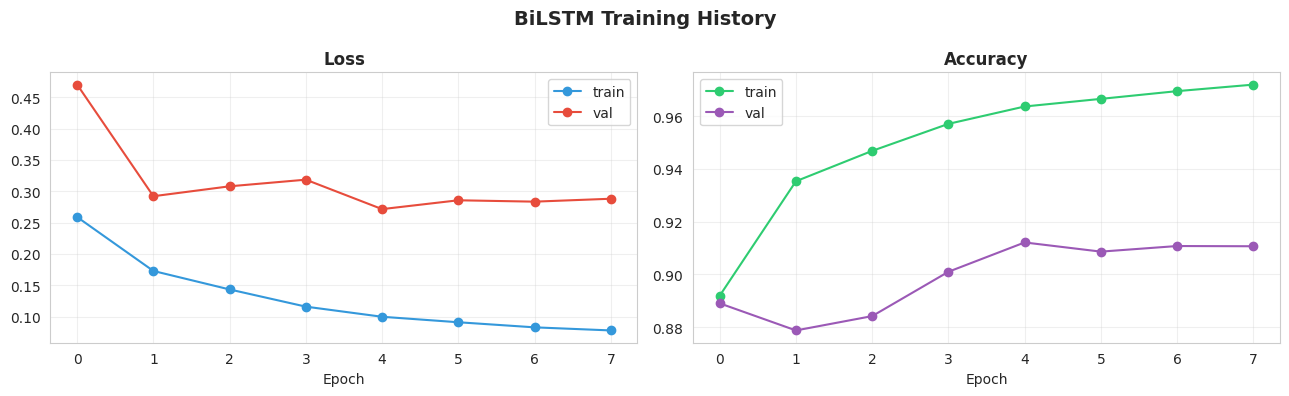

In [125]:
# Training History Visualisation
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(history_bilstm.history['loss'],     'o-', label='train', color='#3498db')
ax[0].plot(history_bilstm.history['val_loss'], 'o-', label='val',   color='#e74c3c')
ax[0].set_title('Loss', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(history_bilstm.history['accuracy'],     'o-', label='train', color='#2ecc71')
ax[1].plot(history_bilstm.history['val_accuracy'], 'o-', label='val',   color='#9b59b6')
ax[1].set_title('Accuracy', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.suptitle('BiLSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Evaluate the BiLSTM

Accuracy, a full classification report and a confusion matrix on the test set.

In [126]:
# Evaluation on ALL THREE splits: Train / Validation / Test
tr_pred  = model_bilstm.predict(X_tr,     batch_size=256, verbose=0).argmax(axis=1)
val_pred = model_bilstm.predict(X_val,    batch_size=256, verbose=0).argmax(axis=1)
probs_bilstm = model_bilstm.predict(X_test_b, batch_size=256, verbose=0)
pred_bilstm  = probs_bilstm.argmax(axis=1)

tr_acc   = (tr_pred  == y_tr).mean()
val_acc  = (val_pred == y_val).mean()
acc_bilstm = (pred_bilstm == y_test_b).mean()

print(f"Train      Accuracy: {tr_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test       Accuracy: {acc_bilstm*100:.2f}%\n")
print(classification_report(y_test_b, pred_bilstm,
      target_names=['Negative','Positive'], digits=3))
p, r, f1, _ = precision_recall_fscore_support(y_test_b, pred_bilstm, average='macro')
print(f"Macro  ->  Precision {p:.3f} | Recall {r:.3f} | F1 {f1:.3f}")


Train      Accuracy: 96.59%
Validation Accuracy: 91.21%
Test       Accuracy: 91.45%

              precision    recall  f1-score   support

    Negative      0.939     0.886     0.912      5882
    Positive      0.893     0.943     0.917      5910

    accuracy                          0.915     11792
   macro avg      0.916     0.914     0.914     11792
weighted avg      0.916     0.915     0.914     11792

Macro  ->  Precision 0.916 | Recall 0.914 | F1 0.914


**Confusion matrix.**

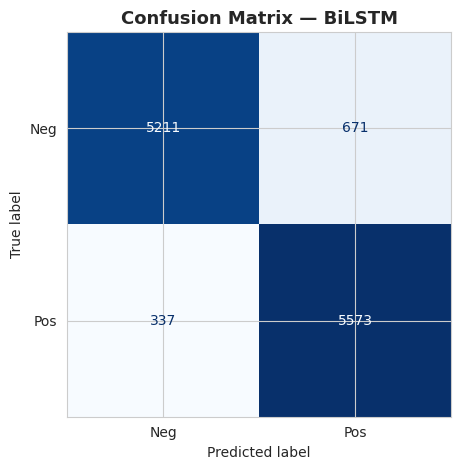

In [127]:
# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test_b, pred_bilstm),
    display_labels=['Neg','Pos']).plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — BiLSTM', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 15. Sequence Feature Extraction

We pass a few reviews through the network up to the pooling layer to see the fixed-length
feature vector the classifier actually uses.

In [128]:
# Feature extraction — sequence embedding (GlobalMaxPooling output)
# Pass three reviews through the model up to the pooling layer to get their feature vector.
sample = X_test_b[:3]
h = model_bilstm.layers[0](sample)              # Embedding
for layer in model_bilstm.layers[1:5]:          # SpatialDropout1D, BiLSTM, BiLSTM, GlobalMaxPool
    h = layer(h, training=False)
features = np.array(h)

print("Extracted sequence-feature shape :", features.shape, "(samples, feature_dim)")
print()
print("Sample 0 feature vector (first 10 dims):")
print(" ", features[0, :10].round(3))

Extracted sequence-feature shape : (3, 64) (samples, feature_dim)

Sample 0 feature vector (first 10 dims):
  [-0.002 -0.013  0.003  0.057  0.069  0.025  0.056 -0.006  0.103  0.04 ]


## 16. Explaining the BiLSTM with LIME

LIME shows which words pushed a single review towards positive or negative.

In [129]:
# Local Explainability with LIME
from lime.lime_text import LimeTextExplainer
explainer_lime = LimeTextExplainer(class_names=['Negative','Positive'])

def predict_proba(texts):
    seq = pad_sequences(
        tokenizer_bilstm.texts_to_sequences([clean_text(t) for t in texts]),
        maxlen=MAX_LEN, padding='post', truncating='post'
    )
    return model_bilstm.predict(seq, verbose=0)

sample = df_bilstm['text'].iloc[0]
lab    = int(predict_proba([sample])[0].argmax())
exp    = explainer_lime.explain_instance(
    sample, predict_proba, num_features=8, num_samples=200, labels=[lab])
print("Text:", sample[:120], "\n")
for w, wt in exp.as_list(label=lab):
    print(f"   {w:18s} {'positive' if wt>0 else 'negative':9s} ({wt:+.3f})")

Text: Management tends to think the success of the store is directly tied to their efforts when the truth is most of the manag 

   grunts             positive  (+0.020)
   due                positive  (+0.019)
   glorified          positive  (+0.019)
   tends              positive  (+0.018)
   folks              positive  (+0.017)
   success            negative  (-0.010)
   Apple              negative  (-0.009)
   products           negative  (-0.004)


## 17. SHAP Explanation for the BiLSTM

SHAP gives word-level importance averaged over a few sample reviews.

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 3/5 [00:13<00:00,  3.39it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 5/5 [00:22<00:00,  2.67s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [00:31,  6.31s/it]                       


SHAP — mean word contribution toward the Positive class (5 sample reviews):


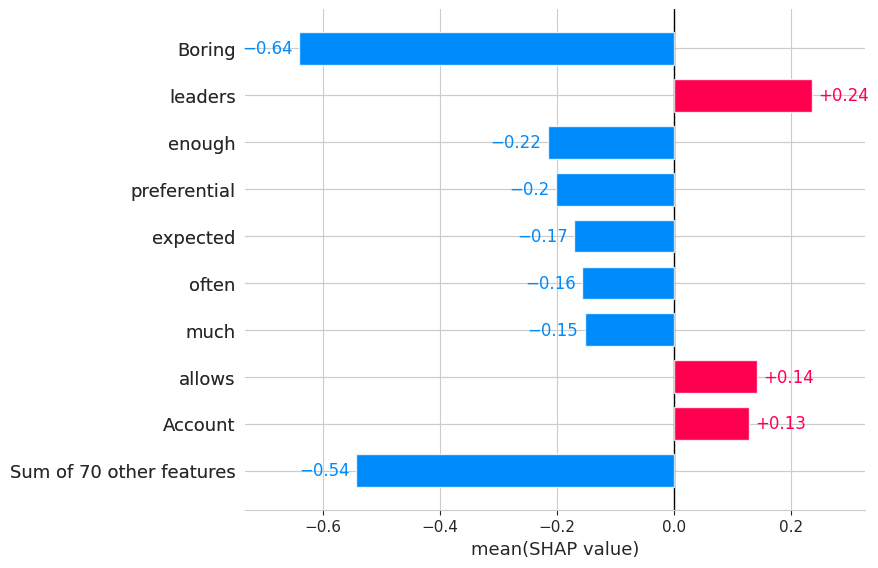

In [130]:
# SHAP Analysis — BiLSTM (Model 1, text)
# Word-level importance with SHAP.
# If SHAP cannot run we rely on the LIME explanation above.
try:
    import shap
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap'], check=False)
    try:
        import shap
    except Exception:
        shap = None

if shap is not None:
    try:
        masker        = shap.maskers.Text(r"\W+")
        _f            = lambda xs: predict_proba(list(xs))     # reuse BiLSTM predict_proba
        explainer_txt = shap.Explainer(_f, masker, output_names=['Negative', 'Positive'])
        sample_texts  = df_bilstm['text'].iloc[:5].astype(str).tolist()
        sv            = explainer_txt(sample_texts)
        print("SHAP — mean word contribution toward the Positive class (5 sample reviews):")
        shap.plots.bar(sv[:, :, 1].mean(0), show=True)
    except Exception as e:
        print(f"SHAP could not run here ({e}). The LIME explanation above gives word-level attribution.")
else:
    print("SHAP is not available here. The LIME explanation above gives word-level attribution.")

## 18. Turn Sentiment into an Attrition-Risk Signal

We treat the probability of a negative review as an attrition-risk score and look at how that
risk is spread across the test reviews.

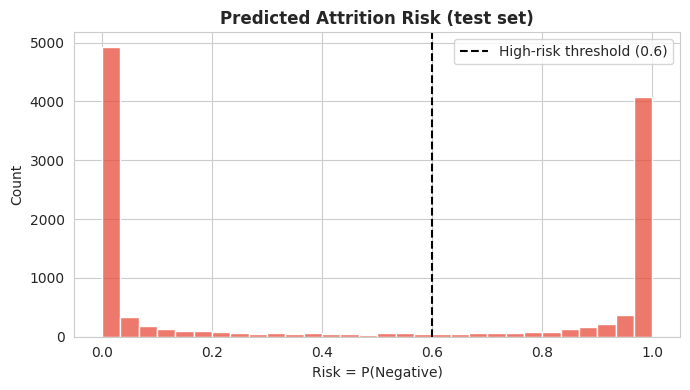

HIGH risk: 45.7%


In [131]:
# Attrition Risk Scoring from Sentiment
def attrition_risk(prob):
    risk  = prob[0]
    level = ('HIGH (likely to leave)' if risk >= 0.6
             else ('MEDIUM (at risk)' if risk >= 0.4 else 'LOW (likely to stay)'))
    return risk, level

test_probs_bilstm = model_bilstm.predict(X_test_b, batch_size=256, verbose=0)
risks = test_probs_bilstm[:, 0]

plt.figure(figsize=(7, 4))
sns.histplot(risks, bins=30, color='#e74c3c')
plt.axvline(0.6, color='k', ls='--', label='High-risk threshold (0.6)')
plt.title('Predicted Attrition Risk (test set)', fontsize=12, fontweight='bold')
plt.xlabel('Risk = P(Negative)')
plt.legend(); plt.tight_layout(); plt.show()
print(f"HIGH risk: {(risks>=0.6).mean()*100:.1f}%")

## 19. Explaining a Single Review

This function classifies one review, assigns a risk level, lists the words that drove the
result with LIME, and writes a short report with a suggested HR action.

In [132]:
# Expandable AI: BiLSTM Individual Explanation

def explain_bilstm_prediction(text, top_k=5, threshold=0.5):
    """
    Full explainability for a single text review using LIME + BiLSTM.

    Returns
    -------
    dict with keys: probability_negative, probability_positive,
                    prediction, risk_level, top_words, explanation_text
    """
    prob = predict_proba([text])[0]         # [P(neg), P(pos)]
    conf = float(max(prob))
    p_neg, p_pos = float(prob[0]), float(prob[1])

    if conf < 0.65:
        prediction  = 'NEUTRAL / MIXED'
        attrition   = 'AT RISK — uncertain signal'
        risk_level  = '🟡 MEDIUM'
    elif p_pos >= threshold:
        prediction  = 'POSITIVE'
        attrition   = 'LIKELY TO STAY'
        risk_level  = '🟢 LOW'
    else:
        prediction  = 'NEGATIVE'
        attrition   = 'LIKELY TO LEAVE'
        risk_level  = '🔴 HIGH'

    # LIME word-level explanation
    lab = int(prob.argmax())
    exp = explainer_lime.explain_instance(
        text, predict_proba, num_features=top_k, num_samples=200, labels=[lab]
    )
    word_weights = exp.as_list(label=lab)

    lines = [
        "=== BiLSTM Explainability Report ===",
        "",
        f"  Text snippet         : \"{text.strip()[:80]}\"",
        f"  Sentiment Prediction : {prediction}",
        f"  Attrition Signal     : {attrition}",
        f"  Risk Level           : {risk_level}",
        f"  P(Positive)          : {p_pos*100:.1f}%",
        f"  P(Negative)          : {p_neg*100:.1f}%",
        "",
        f"  Top {top_k} Words Driving Prediction (LIME):",
    ]
    for rank, (word, weight) in enumerate(word_weights, 1):
        direction = f"pushes {'POSITIVE ↑' if weight > 0 else 'NEGATIVE ↓'}"
        lines.append(f"    {rank}. {word:20s}  weight={weight:+.4f}  ({direction})")
    lines += [
        "",
        "  HR Action Recommendation:",
        f"    {'⚠️  Flag for retention interview. Review workload & compensation.' if 'LEAVE' in attrition else '✅  No immediate action needed. Maintain engagement.'}",
        "=" * 40
    ]

    return {
        "probability_negative": p_neg,
        "probability_positive": p_pos,
        "prediction"          : prediction,
        "risk_level"          : risk_level,
        "top_words"           : word_weights,
        "explanation_text"    : "\n".join(lines)
    }


# ─── Example usage ───
test_reviews = [
    "Great pay, supportive managers and amazing work culture.",
    "Toxic management, low salary, long hours, no growth.",
    "The job is okay, average pay, nothing special.",
]
for review in test_reviews:
    result = explain_bilstm_prediction(review)
    print(result["explanation_text"])
    print()

=== BiLSTM Explainability Report ===

  Text snippet         : "Great pay, supportive managers and amazing work culture."
  Sentiment Prediction : POSITIVE
  Attrition Signal     : LIKELY TO STAY
  Risk Level           : 🟢 LOW
  P(Positive)          : 100.0%
  P(Negative)          : 0.0%

  Top 5 Words Driving Prediction (LIME):
    1. Great                 weight=+0.0632  (pushes POSITIVE ↑)
    2. amazing               weight=+0.0573  (pushes POSITIVE ↑)
    3. supportive            weight=+0.0566  (pushes POSITIVE ↑)
    4. pay                   weight=+0.0443  (pushes POSITIVE ↑)
    5. culture               weight=+0.0328  (pushes POSITIVE ↑)

  HR Action Recommendation:
    ✅  No immediate action needed. Maintain engagement.

=== BiLSTM Explainability Report ===

  Text snippet         : "Toxic management, low salary, long hours, no growth."
  Sentiment Prediction : NEGATIVE
  Attrition Signal     : LIKELY TO LEAVE
  Risk Level           : 🔴 HIGH
  P(Positive)          : 0.4%
  P

## 20. Real-Time Feedback Analysis

A simple wrapper to analyse any new piece of employee feedback on the spot.

In [133]:
# Real-Time Feedback Analysis Function
def analyze_feedback(text):
    result = explain_bilstm_prediction(text)
    print(result["explanation_text"])
    return result["prediction"]

# Built-in test cases
for t in ["Great pay, supportive managers and amazing work culture.",
          "Toxic management, low salary, long hours, no growth.",
          "The job is okay, average pay, nothing special."]:
    analyze_feedback(t)

=== BiLSTM Explainability Report ===

  Text snippet         : "Great pay, supportive managers and amazing work culture."
  Sentiment Prediction : POSITIVE
  Attrition Signal     : LIKELY TO STAY
  Risk Level           : 🟢 LOW
  P(Positive)          : 100.0%
  P(Negative)          : 0.0%

  Top 5 Words Driving Prediction (LIME):
    1. amazing               weight=+0.0747  (pushes POSITIVE ↑)
    2. supportive            weight=+0.0688  (pushes POSITIVE ↑)
    3. Great                 weight=+0.0536  (pushes POSITIVE ↑)
    4. pay                   weight=+0.0389  (pushes POSITIVE ↑)
    5. culture               weight=+0.0334  (pushes POSITIVE ↑)

  HR Action Recommendation:
    ✅  No immediate action needed. Maintain engagement.
=== BiLSTM Explainability Report ===

  Text snippet         : "Toxic management, low salary, long hours, no growth."
  Sentiment Prediction : NEGATIVE
  Attrition Signal     : LIKELY TO LEAVE
  Risk Level           : 🔴 HIGH
  P(Positive)          : 0.4%
  P(

In [134]:
# Custom Feedback Input
analyze_feedback("Admire is too worst, and pay rate is also too low, and opportunities are also too few.")

=== BiLSTM Explainability Report ===

  Text snippet         : "Admire is too worst, and pay rate is also too low, and opportunities are also to"
  Sentiment Prediction : NEGATIVE
  Attrition Signal     : LIKELY TO LEAVE
  Risk Level           : 🔴 HIGH
  P(Positive)          : 6.0%
  P(Negative)          : 94.0%

  Top 5 Words Driving Prediction (LIME):
    1. worst                 weight=+0.4734  (pushes POSITIVE ↑)
    2. low                   weight=+0.2012  (pushes POSITIVE ↑)
    3. pay                   weight=-0.1248  (pushes NEGATIVE ↓)
    4. Admire                weight=-0.1238  (pushes NEGATIVE ↓)
    5. opportunities         weight=-0.0937  (pushes NEGATIVE ↓)

  HR Action Recommendation:
    ⚠️  Flag for retention interview. Review workload & compensation.


'NEGATIVE'

## 21. Save the BiLSTM

We save the model, the tokenizer and the label map so it can be reused for new reviews later.

In [135]:
# Save BiLSTM Model
import pickle, os

SAVE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else (
           '/content'        if os.path.isdir('/content')        else '.')

BILSTM_KERAS = os.path.join(SAVE_DIR, 'bilstm_sentiment_model.keras')
BILSTM_H5    = os.path.join(SAVE_DIR, 'bilstm_sentiment_model.h5')
BILSTM_TOK   = os.path.join(SAVE_DIR, 'bilstm_tokenizer.pkl')
BILSTM_LMAP  = os.path.join(SAVE_DIR, 'bilstm_label_map.pkl')

# ── 1) Native Keras format (.keras) — Keras 3 / TF 2.12+ ──
model_bilstm.save(BILSTM_KERAS)

# ── 2) Legacy HDF5 format (.h5) — broadest compatibility ──
try:
    model_bilstm.save(BILSTM_H5)
    h5_saved = True
except Exception as e:
    h5_saved = False
    print(f"  ℹ️  .h5 skipped: {e}")

# ── 3) Tokenizer (required to vectorise new text at inference time) ──
with open(BILSTM_TOK, 'wb') as f:
    pickle.dump(tokenizer_bilstm, f)

# ── 4) Label map ──
with open(BILSTM_LMAP, 'wb') as f:
    pickle.dump(inv_label_map, f)

# ── 5) Verify every file exists on disk ──
missing = [p for p in [BILSTM_KERAS, BILSTM_TOK, BILSTM_LMAP] if not os.path.isfile(p)]
assert not missing, f"❌ Missing files: {missing}"

keras_mb = os.path.getsize(BILSTM_KERAS) / 1e6
tok_kb   = os.path.getsize(BILSTM_TOK)   / 1e3
lmap_kb  = os.path.getsize(BILSTM_LMAP)  / 1e3

print("=" * 55)
print("  ✅ BiLSTM — Model Files Saved Successfully")
print("=" * 55)
print(f"  📁 {BILSTM_KERAS}")
print(f"      Size : {keras_mb:.2f} MB")
if h5_saved:
    h5_mb = os.path.getsize(BILSTM_H5) / 1e6
    print(f"  📁 {BILSTM_H5}")
    print(f"      Size : {h5_mb:.2f} MB")
print(f"  📁 {BILSTM_TOK}")
print(f"      Size : {tok_kb:.2f} KB")
print(f"  📁 {BILSTM_LMAP}")
print(f"      Size : {lmap_kb:.2f} KB")
print("=" * 55)
print()
print("  ── How to Reload BiLSTM ──")
print("  from tensorflow.keras.models import load_model")
print("  import pickle")
print(f"  loaded_bilstm = load_model('{BILSTM_KERAS}')")
print(f"  with open('{BILSTM_TOK}', 'rb') as f:")
print("      loaded_tokenizer  = pickle.load(f)")
print(f"  with open('{BILSTM_LMAP}', 'rb') as f:")
print("      loaded_label_map  = pickle.load(f)")

  ✅ BiLSTM — Model Files Saved Successfully
  📁 /kaggle/working/bilstm_sentiment_model.keras
      Size : 32.53 MB
  📁 /kaggle/working/bilstm_sentiment_model.h5
      Size : 32.53 MB
  📁 /kaggle/working/bilstm_tokenizer.pkl
      Size : 986.53 KB
  📁 /kaggle/working/bilstm_label_map.pkl
      Size : 0.04 KB

  ── How to Reload BiLSTM ──
  from tensorflow.keras.models import load_model
  import pickle
  loaded_bilstm = load_model('/kaggle/working/bilstm_sentiment_model.keras')
  with open('/kaggle/working/bilstm_tokenizer.pkl', 'rb') as f:
      loaded_tokenizer  = pickle.load(f)
  with open('/kaggle/working/bilstm_label_map.pkl', 'rb') as f:
      loaded_label_map  = pickle.load(f)


## 22. Model 2 — CNN-BiGRU with Attention

Our second text model combines convolution (to catch short phrases like "low salary"),
bidirectional GRUs (for sequence context) and a learnable attention layer (to focus on the
words that matter). It is trained on the same data as the BiLSTM for a fair comparison.

In [136]:
# CNN-BiGRU with Attention — advanced second model for comparison
from tensorflow.keras.layers import Input, Conv1D, GRU, Layer
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

tf.random.set_seed(SEED); np.random.seed(SEED)

class AttentionPool(Layer):
    """Additive (Bahdanau-style) attention pooling over the time dimension."""
    def build(self, input_shape):
        d = int(input_shape[-1])
        self.W = self.add_weight(name='att_W', shape=(d, d),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_b', shape=(d,),
                                 initializer='zeros', trainable=True)
        self.u = self.add_weight(name='att_u', shape=(d, 1),
                                 initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, x):
        score   = K.tanh(K.dot(x, self.W) + self.b)   # (batch, time, d)
        score   = K.dot(score, self.u)                # (batch, time, 1)
        weights = K.softmax(score, axis=1)            # attention weights over time
        return K.sum(weights * x, axis=1)             # context vector (batch, d)

inp = Input(shape=(MAX_LEN,))
x   = Embedding(input_dim=VOCAB, output_dim=EMBED_DIM)(inp)
x   = SpatialDropout1D(0.3)(x)
x   = Conv1D(128, 3, padding='same', activation='relu')(x)   # local n-gram features
x   = Conv1D(64,  3, padding='same', activation='relu')(x)
x   = Bidirectional(GRU(64, return_sequences=True))(x)       # sequential context
x   = Bidirectional(GRU(32, return_sequences=True))(x)
x   = AttentionPool()(x)                                     # learnable pooling
x   = Dense(64, activation='relu')(x)
x   = BatchNormalization()(x)
x   = Dropout(0.4)(x)
out = Dense(2, activation='softmax')(x)

model_bigru = Model(inp, out, name='CNN_BiGRU_Attention')
model_bigru.compile(optimizer=Adam(learning_rate=1e-3),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_bigru.summary()

Model: "CNN_BiGRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 80, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 80, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 80, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 80, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 80, 128)        │        49,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 80, 64)         │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pool (AttentionPool)  │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,723,714 (10.39 MB)

 Trainable params: 2,723,586 (10.39 MB)

 Non-trainable params: 128 (512.00 B)

**Train the CNN-BiGRU-Attention model.**

In [137]:
# Train CNN-BiGRU-Attention
es_bigru  = EarlyStopping(monitor='val_accuracy', patience=3,
                          restore_best_weights=True, verbose=1)
rlr_bigru = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=1, min_lr=1e-5, verbose=1)

history_bigru = model_bigru.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[es_bigru, rlr_bigru],
    verbose=1
)

Epoch 1/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 122s 523ms/step - accuracy: 0.8750 - loss: 0.2802 - val_accuracy: 0.9017 - val_loss: 0.2641 - learning_rate: 0.0010
Epoch 2/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9324 - loss: 0.1765
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
215/215 ━━━━━━━━━━━━━━━━━━━━ 110s 513ms/step - accuracy: 0.9369 - loss: 0.1668 - val_accuracy: 0.8946 - val_loss: 0.2811 - learning_rate: 0.0010
Epoch 3/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 110s 513ms/step - accuracy: 0.9541 - loss: 0.1274 - val_accuracy: 0.9122 - val_loss: 0.2343 - learning_rate: 5.0000e-04
Epoch 4/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9579 - loss: 0.1150
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
215/215 ━━━━━━━━━━━━━━━━━━━━ 114s 532ms/step - accuracy: 0.9610 - loss: 0.1076 - val_accuracy: 0.9085 - val_loss: 0.2555 - learning_rate: 5.0000e-04
Epoch 5/12
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accura

**Learning curves.**

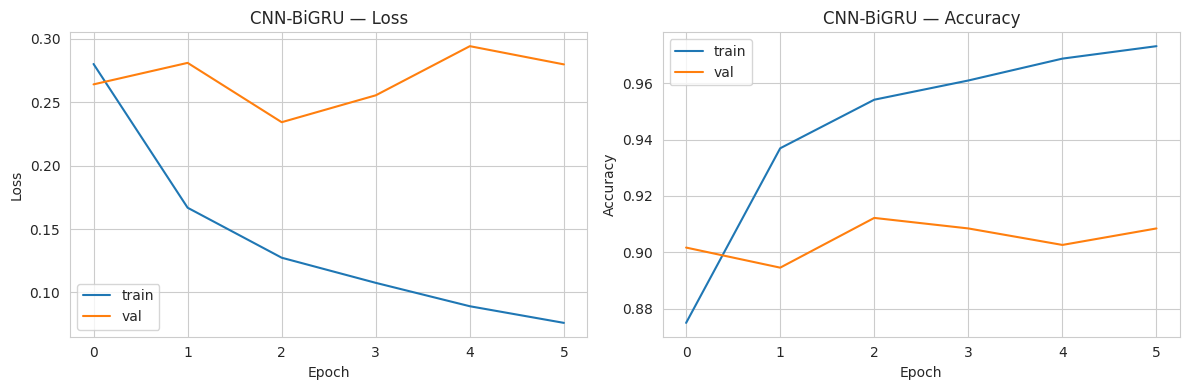

In [138]:
# Learning curves — CNN-BiGRU-Attention
h = history_bigru.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('CNN-BiGRU — Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend()
ax[1].plot(h['accuracy'], label='train'); ax[1].plot(h['val_accuracy'], label='val')
ax[1].set_title('CNN-BiGRU — Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

**Test-set evaluation.**

Test Accuracy: 91.53% | ROC-AUC: 0.974

              precision    recall  f1-score   support

    Negative      0.940     0.887     0.913      5882
    Positive      0.894     0.943     0.918      5910

    accuracy                          0.915     11792
   macro avg      0.917     0.915     0.915     11792
weighted avg      0.917     0.915     0.915     11792

Macro  ->  Precision 0.917 | Recall 0.915 | F1 0.915
ℹ️ Accuracy 91.53% (target >= 95%).


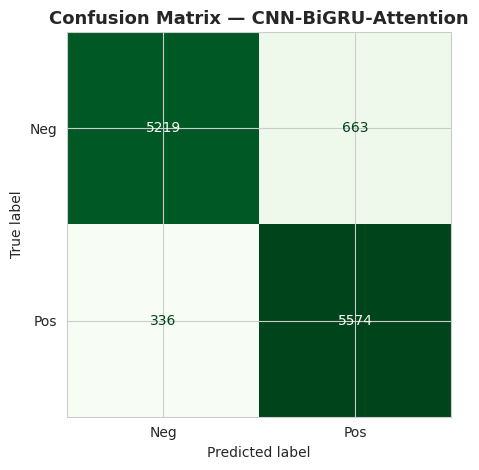

In [139]:
# Test-set evaluation — CNN-BiGRU-Attention
from sklearn.metrics import roc_auc_score

probs_bigru = model_bigru.predict(X_test_b, batch_size=256, verbose=0)
pred_bigru  = probs_bigru.argmax(axis=1)
acc_bigru   = (pred_bigru == y_test_b).mean()
auc_bigru   = roc_auc_score(y_test_b, probs_bigru[:, 1])

print(f"Test Accuracy: {acc_bigru*100:.2f}% | ROC-AUC: {auc_bigru:.3f}\n")
print(classification_report(y_test_b, pred_bigru,
      target_names=['Negative', 'Positive'], digits=3))
p, r, f1, _ = precision_recall_fscore_support(y_test_b, pred_bigru, average='macro')
print(f"Macro  ->  Precision {p:.3f} | Recall {r:.3f} | F1 {f1:.3f}")

TARGET_ACC = 0.95
print("✅ Target reached: accuracy >= 95%."
      if acc_bigru >= TARGET_ACC
      else f"ℹ️ Accuracy {acc_bigru*100:.2f}% (target >= 95%).")

ConfusionMatrixDisplay(confusion_matrix(y_test_b, pred_bigru),
    display_labels=['Neg', 'Pos']).plot(cmap='Greens', colorbar=False)
plt.title('Confusion Matrix — CNN-BiGRU-Attention', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**LIME explanation for the CNN-BiGRU model.**

In [140]:
# Local explainability (LIME) — CNN-BiGRU-Attention
# Use the same LIME explainer with this model's prediction function.
def predict_proba_bigru(texts):
    seq = pad_sequences(
        tokenizer_bilstm.texts_to_sequences([clean_text(t) for t in texts]),
        maxlen=MAX_LEN, padding='post', truncating='post'
    )
    return model_bigru.predict(seq, verbose=0)

sample = df_bilstm['text'].iloc[0]
lab    = int(predict_proba_bigru([sample])[0].argmax())
exp    = explainer_lime.explain_instance(
    sample, predict_proba_bigru, num_features=8, num_samples=200, labels=[lab])
print("Text:", sample[:120], "\n")
for w, wt in exp.as_list(label=lab):
    print(f"   {w:18s} {'positive' if wt > 0 else 'negative':9s} ({wt:+.3f})")

Text: Management tends to think the success of the store is directly tied to their efforts when the truth is most of the manag 

   glorified          positive  (+0.039)
   tends              positive  (+0.030)
   due                positive  (+0.023)
   success            negative  (-0.023)
   folks              positive  (+0.022)
   Management         positive  (+0.018)
   grunts             positive  (+0.016)
   Apple              negative  (-0.016)


**Save the CNN-BiGRU-Attention model.**

In [141]:
# Save CNN-BiGRU-Attention
import os
SAVE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else (
           '/content'        if os.path.isdir('/content')        else '.')
BIGRU_KERAS = os.path.join(SAVE_DIR, 'cnn_bigru_attention_sentiment.keras')

model_bigru.save(BIGRU_KERAS)
assert os.path.isfile(BIGRU_KERAS), f"❌ File not found: {BIGRU_KERAS}"
print(f"✅ CNN-BiGRU-Attention saved -> {BIGRU_KERAS}  ({os.path.getsize(BIGRU_KERAS)/1e6:.2f} MB)")
print("  Reload: from tensorflow.keras.models import load_model")
print("          load_model(path, custom_objects={'AttentionPool': AttentionPool})")

✅ CNN-BiGRU-Attention saved -> /kaggle/working/cnn_bigru_attention_sentiment.keras  (32.78 MB)
  Reload: from tensorflow.keras.models import load_model
          load_model(path, custom_objects={'AttentionPool': AttentionPool})


## 23. Compare the Two Sentiment Models

Both models are scored on the same test set across accuracy, precision, recall, F1 and ROC-AUC.

Part B — Sentiment model comparison:

                    Accuracy Precision  Recall      F1 ROC-AUC
BiLSTM                91.45%    89.25%   94.3%  91.71%  97.07%
CNN-BiGRU-Attention   91.53%    89.37%  94.31%  91.78%  97.45%


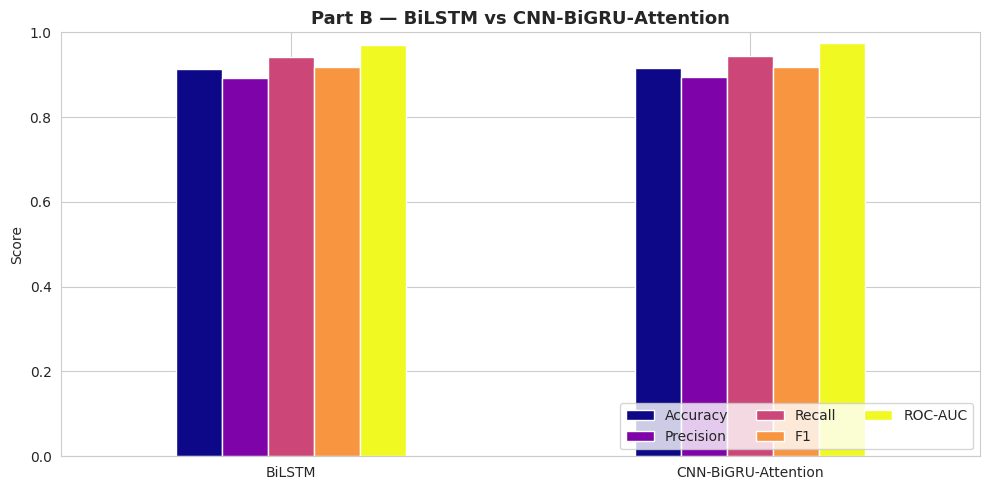


🏆 Higher F1 on the held-out test set: CNN-BiGRU-Attention


In [142]:
# Model comparison — BiLSTM vs CNN-BiGRU-Attention
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

def _metrics_txt(y_true, y_pred, y_prob_pos):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1)
    return {'Accuracy' : (y_pred == y_true).mean(),
            'Precision': p, 'Recall': r, 'F1': f1,
            'ROC-AUC'  : roc_auc_score(y_true, y_prob_pos)}

cmp_B = pd.DataFrame({
    'BiLSTM'             : _metrics_txt(y_test_b, pred_bilstm, probs_bilstm[:, 1]),
    'CNN-BiGRU-Attention': _metrics_txt(y_test_b, pred_bigru,  probs_bigru[:, 1]),
}).T

print("Part B — Sentiment model comparison:\n")
print((cmp_B * 100).round(2).astype(str) + '%')

cmp_B.plot(kind='bar', figsize=(10, 5), colormap='plasma')
plt.title('Part B — BiLSTM vs CNN-BiGRU-Attention', fontsize=13, fontweight='bold')
plt.ylabel('Score'); plt.ylim(0, 1); plt.xticks(rotation=0)
plt.legend(loc='lower right', ncol=3); plt.tight_layout(); plt.show()

winner_B = cmp_B['F1'].idxmax()
print(f"\n🏆 Higher F1 on the held-out test set: {winner_B}")

## 24. Precision-Recall Curves

PR-AUC and precision-recall curves for both sentiment models.

PR-AUC (Average Precision) on the held-out test set:
   BiLSTM              : 0.971
   CNN-BiGRU-Attention : 0.976


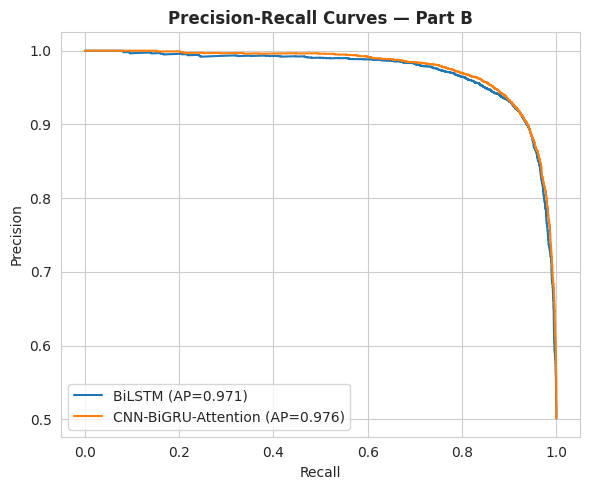

In [143]:
# PR-AUC & Precision-Recall Curves (both sentiment models)
from sklearn.metrics import average_precision_score, precision_recall_curve
pr_bi = average_precision_score(y_test_b, probs_bilstm[:, 1])
pr_bg = average_precision_score(y_test_b, probs_bigru[:, 1])
print("PR-AUC (Average Precision) on the held-out test set:")
print(f"   BiLSTM              : {pr_bi:.3f}")
print(f"   CNN-BiGRU-Attention : {pr_bg:.3f}")

plt.figure(figsize=(6, 5))
for name, pp in [('BiLSTM', probs_bilstm[:, 1]),
                 ('CNN-BiGRU-Attention', probs_bigru[:, 1])]:
    prec, rec, _ = precision_recall_curve(y_test_b, pp)
    plt.plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test_b, pp):.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Part B', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

# Conclusion

Both pipelines are complete and reproduce the same results under `SEED = 42`.

- **Part 1** predicts employee attrition from structured HR data with an FT-Transformer and a
  Tabular ResNet, and explains each prediction with attention and SHAP.
- **Part 2** classifies the sentiment of employee reviews with a BiLSTM and a CNN-BiGRU-Attention
  model, explains the words behind each decision with LIME and SHAP, and converts sentiment into
  an attrition-risk signal.

Together they connect *what the numbers say* and *what employees actually write* into one view
of why people leave.

## Deployment — Save Sentiment Models & Artifacts

In [144]:
# Deployment - Save Sentiment Models & Preprocessing Artifacts (Hugging Face Spaces ready)
import os, joblib

DEPLOY_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else (
             '/content' if os.path.isdir('/content') else '.')
PREFIX = 'employee_sentiment_significant_cv'

model_bilstm.save(os.path.join(DEPLOY_DIR, f'{PREFIX}_bilstm.h5'))
model_bigru.save(os.path.join(DEPLOY_DIR, f'{PREFIX}_bigru.h5'))

joblib.dump(tokenizer_bilstm, os.path.join(DEPLOY_DIR, f'{PREFIX}_tokenizer.pkl'))
joblib.dump({'MAX_LEN': MAX_LEN, 'MAX_WORDS': MAX_WORDS, 'VOCAB': VOCAB},
            os.path.join(DEPLOY_DIR, f'{PREFIX}_text_config.pkl'))
if 'inv_label_map' in globals():
    joblib.dump(inv_label_map, os.path.join(DEPLOY_DIR, f'{PREFIX}_label_map.pkl'))

print('Saved sentiment models and preprocessing artifacts to', DEPLOY_DIR)

Saved sentiment models and preprocessing artifacts to /kaggle/working
